# Practice 2: Transfer Learning on CIFAR-10

This notebook is the presentation and analysis layer for Practice 2. The reusable implementation remains in `processing_own_phase`; the notebook does not duplicate the training pipeline.

**Workflow:** define the problem → audit data → prevent leakage → establish a baseline → run controlled experiments → select by validation → verify the checkpoint → evaluate test once → analyze errors.

## Phase 1 - Problem Definition

| Item | Definition |
|---|---|
| Task | Supervised, single-label, 10-class image classification |
| Input | CIFAR-10 RGB image, originally `3 × 32 × 32` |
| Model input | Image resized/cropped to `3 × 224 × 224` and normalized with ImageNet statistics |
| Output | Ten raw logits, one per CIFAR-10 class |
| Primary metric | Validation/test accuracy |
| Secondary metrics | Macro F1, per-class precision and recall |
| Model family | ImageNet-pretrained CNNs from TorchVision |
| Main constraint | Training time and memory on CPU/MPS hardware |

The official CIFAR-10 test set is excluded from model and hyperparameter selection. Experiments are compared on validation data. Only the selected checkpoint is eligible for final test evaluation.

## Phase 2 - Environment Setup

The following setup works when the notebook is opened from either the project root or the `notebooks` directory.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from IPython.display import Image, Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_CANDIDATES = (CURRENT_DIR, CURRENT_DIR.parent)
PROJECT_ROOT = next(
    path
    for path in PROJECT_CANDIDATES
    if (path / "processing_own_phase").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs import CLASS_NAMES, CONFIG, EXPERIMENTS, OUTPUT_DIR, REPORTS_DIR, RUNS_DIR
from processing_own_phase.visualize import (
    plot_experiment_comparison,
    plot_validation_test_comparison,
)

def colored_table(dataframe, caption, gradient_columns=None, boolean_columns=None):
    """Create a colored table for notebook presentation."""
    gradient_columns = gradient_columns or []
    boolean_columns = boolean_columns or []
    styler = dataframe.style.set_caption(caption).set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"), ("font-size", "17px"),
            ("font-weight", "bold"), ("color", "#5dade2"), ("padding", "10px")
        ]},
        {"selector": "thead th", "props": [
            ("background-color", "#1f4e78"), ("color", "white"),
            ("font-weight", "bold"), ("text-align", "center"),
            ("padding", "9px 13px"), ("border", "1px solid #5b9bd5")
        ]},
        {"selector": "tbody tr:nth-child(even)", "props": [
            ("background-color", "rgba(91, 155, 213, 0.15)")
        ]},
        {"selector": "tbody tr:hover", "props": [
            ("background-color", "rgba(91, 155, 213, 0.30)")
        ]},
        {"selector": "td", "props": [
            ("padding", "8px 13px"),
            ("border-bottom", "1px solid rgba(127, 127, 127, 0.35)"),
            ("text-align", "center")
        ]},
    ])
    gradient_columns = [c for c in gradient_columns if c in dataframe.columns]
    if gradient_columns:
        styler = styler.background_gradient(cmap="Blues", subset=gradient_columns)
    boolean_columns = [c for c in boolean_columns if c in dataframe.columns]
    if boolean_columns:
        styler = styler.map(
            lambda value: (
                "background-color: #198754; color: white; font-weight: bold"
                if value is True else
                "background-color: #6c757d; color: white"
            ),
            subset=boolean_columns,
        )
    return styler

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"Project root: {PROJECT_ROOT}")

# Persistent evidence of the accelerator used by the selected controlled run.
from processing_own_phase.utils import get_device

selection_record = json.loads(
    (OUTPUT_DIR / "controlled_experiment_selection.json").read_text()
)
selected_checkpoint = Path(selection_record["selected_checkpoint"])
training_log = next(selected_checkpoint.parent.glob("*.log"))
device_log_line = next(
    line for line in training_log.read_text().splitlines()
    if "Using device:" in line
)
training_device = device_log_line.rsplit("Using device:", 1)[1].strip().lower()

final_summary = json.loads((OUTPUT_DIR / "summary.json").read_text())
final_device = str(final_summary["device"]).lower()
runtime_device = str(get_device()).lower()
gpu_backends = {"cuda", "mps"}

assert training_device in gpu_backends, (
    f"Selected run was not GPU accelerated: {training_device}"
)
assert selection_record["test_data_used"] is False

gpu_evidence = pd.DataFrame([
    {
        "stage": "Controlled training (selected E2)",
        "evidence_source": str(training_log.relative_to(PROJECT_ROOT)),
        "device": training_device,
        "gpu_accelerated": training_device in gpu_backends,
        "meaning": "Apple GPU through Metal" if training_device == "mps" else "NVIDIA GPU through CUDA",
    },
    {
        "stage": "Final evaluation",
        "evidence_source": "outputs/summary.json",
        "device": final_device,
        "gpu_accelerated": final_device in gpu_backends,
        "meaning": "Recorded final-evaluation device",
    },
    {
        "stage": "Current notebook runtime",
        "evidence_source": "live torch backend check",
        "device": runtime_device,
        "gpu_accelerated": runtime_device in gpu_backends,
        "meaning": "Best accelerator currently available",
    },
])

display(Markdown(
    "### GPU Training Evidence\n"
    "The selected checkpoint's persistent training log records `Using device: mps`. "
    "Therefore E2 was trained on the Apple GPU through Metal Performance Shaders, "
    "not inferred only from the current runtime. This cell does not retrain the model."
))
display(colored_table(
    gpu_evidence,
    "GPU accelerator evidence",
    boolean_columns=["gpu_accelerated"],
))

Python: 3.11.14
PyTorch: 2.13.0
TorchVision: 0.28.0
Project root: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2


### GPU Training Evidence
The selected checkpoint's persistent training log records `Using device: mps`. Therefore E2 was trained on the Apple GPU through Metal Performance Shaders, not inferred only from the current runtime. This cell does not retrain the model.

,stage,evidence_source,device,gpu_accelerated,meaning
0,Controlled training (selected E2),runs/E2_resnet18_partial_baf0fc38/E2_resnet18_partial_baf0fc38.log,mps,True,Apple GPU through Metal
1,Final evaluation,outputs/summary.json,mps,True,Recorded final-evaluation device
2,Current notebook runtime,live torch backend check,mps,True,Best accelerator currently available


## Phase 3 - Data Loading

CIFAR-10 contains 50,000 official training images and 10,000 official test images. The project creates a reproducible train/validation split from the official training pool.

- Training data uses random crop, horizontal flip, color jitter and ImageNet normalization.
- Validation and test use deterministic resize, center crop and the same normalization.
- Training and validation indices must be disjoint.
- Test data must not influence preprocessing choices, experiment selection or checkpoint selection.

CIFAR-10 is balanced, but a future revision should use an explicitly stratified split so every class count is guaranteed rather than merely expected.

In [2]:
from processing_own_phase.data import get_class_distribution, load_datasets

train_subset, val_subset, test_dataset = load_datasets(
    data_dir=CONFIG["data_dir"],
    val_ratio=1.0 - CONFIG["train_split_ratio"],
    seed=CONFIG["seed"],
)

train_indices = set(train_subset.indices)
val_indices = set(val_subset.indices)
assert train_indices.isdisjoint(val_indices)
assert len(train_subset) == 45_000
assert len(val_subset) == 5_000
assert len(test_dataset) == 10_000

split_summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "samples": [len(train_subset), len(val_subset), len(test_dataset)],
        "random_augmentation": [True, False, False],
        "used_for_selection": [False, True, False],
        "used_for_final_test": [False, False, True],
    }
)
display(Markdown(
    "**Leakage control:** split indices are determined before dataset views with "
    "preprocessing are constructed. TorchVision transforms run lazily only when "
    "an image is accessed."
))
display(colored_table(
    split_summary,
    "Dataset split summary",
    gradient_columns=["samples"],
    boolean_columns=[
        "random_augmentation",
        "used_for_selection",
        "used_for_final_test",
    ],
))

**Leakage control:** split indices are determined before dataset views with preprocessing are constructed. TorchVision transforms run lazily only when an image is accessed.

,split,samples,random_augmentation,used_for_selection,used_for_final_test
0,Train,45000,True,False,False
1,Validation,5000,False,True,False
2,Test,10000,False,False,True


## Phase 4 - Exploratory Data Analysis

EDA follows the same presentation pattern as Practice 1 while respecting the CIFAR-10 split boundary. Pixel-level analysis uses only the 45,000-image training subset; Validation and Test pixels are not inspected. The Test class counts remain visible only as a fixed dataset-integrity property.

The phase covers the raw RGB contract, class balance, channel and pixel intensity, image brightness and contrast, exact-duplicate and quality checks, representative samples, class-average images, statistical extremes, and a deterministic PCA/t-SNE projection. All findings are descriptive and do not select the model.

### EDA scope and raw-data contract

,item,value
0,EDA scope,Training subset only
1,Samples,"45,000"
2,Raw shape,"(45000, 32, 32, 3)"
3,Raw dtype,uint8
4,Raw range,"[0, 255]"
5,Label range,"[0, 9]"


### Class distribution

,Train,Validation,Test
airplane,4512,488,1000
automobile,4488,512,1000
bird,4468,532,1000
cat,4529,471,1000
deer,4529,471,1000
dog,4486,514,1000
frog,4493,507,1000
horse,4500,500,1000
ship,4496,504,1000
truck,4499,501,1000


### RGB intensity, brightness and contrast

,channel,mean,std,minimum,maximum
0,Red,0.491655,0.247081,0.000000,1.000000
1,Green,0.482333,0.243509,0.000000,1.000000
2,Blue,0.446679,0.261581,0.000000,1.000000


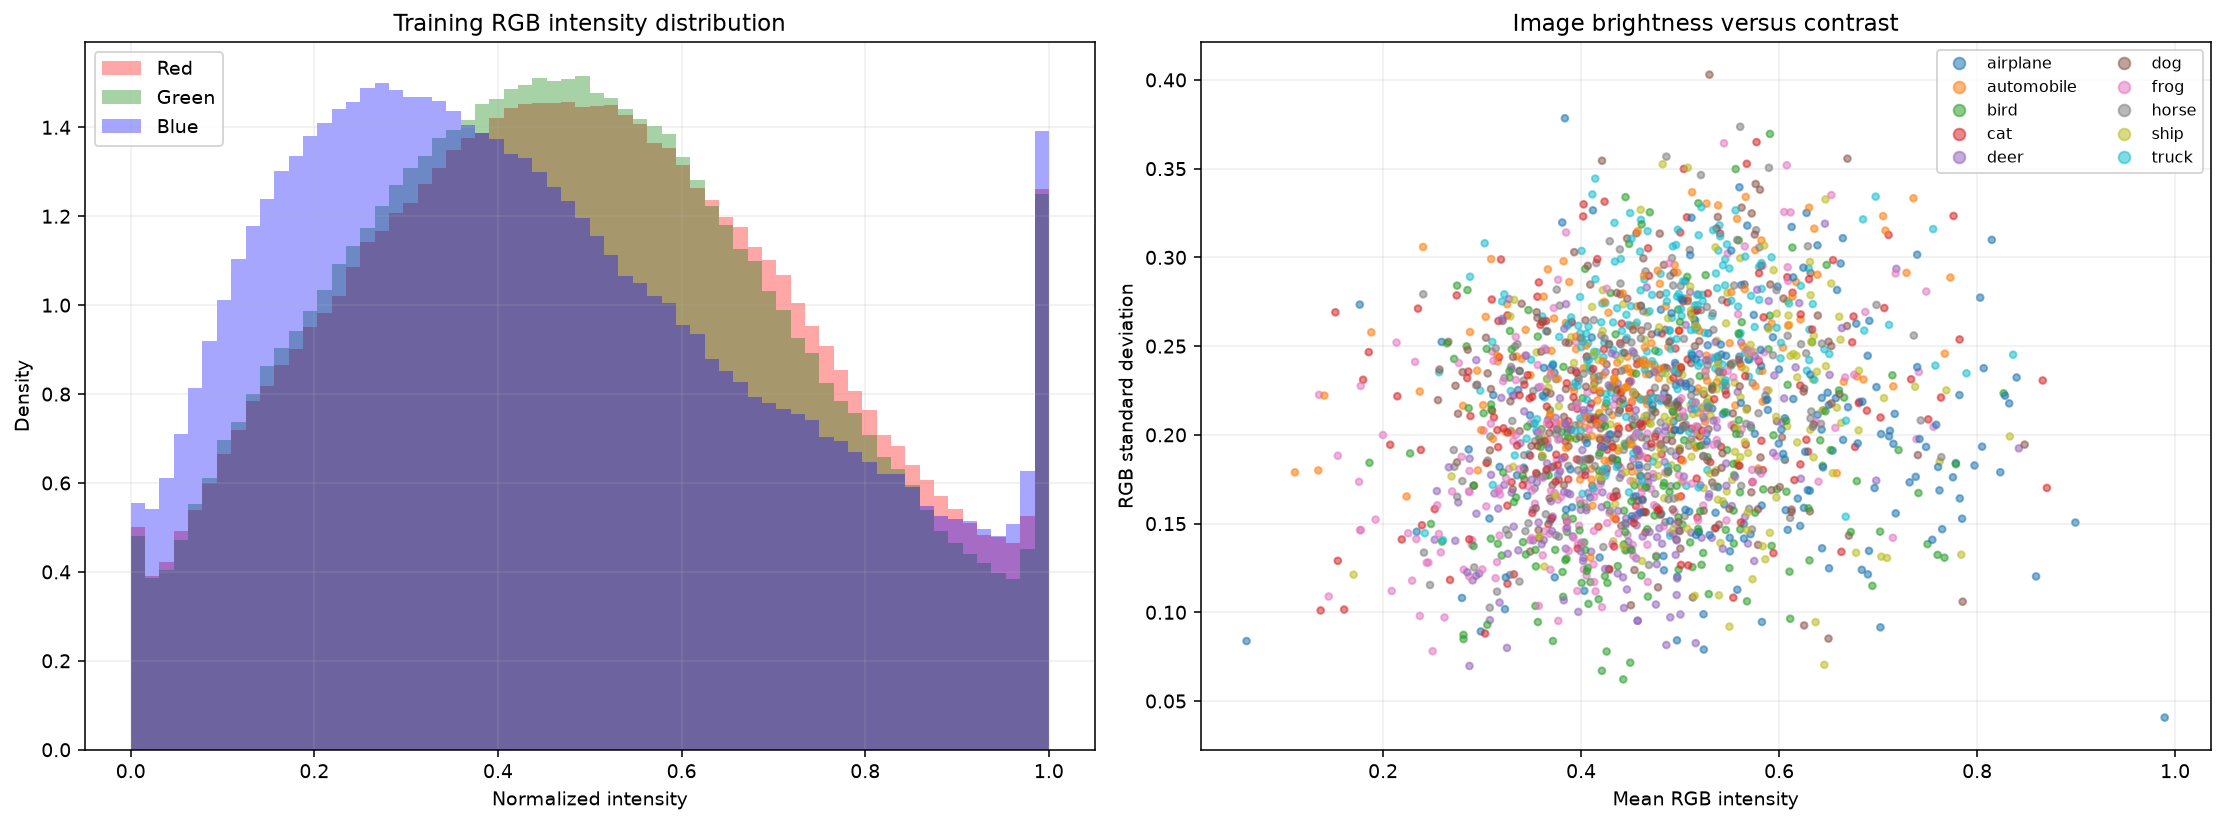

### Data quality and exact-duplicate audit

,check,value
0,Non-finite pixels,0
1,Invalid labels,0
2,Missing classes,0
3,Constant images,0
4,Exact duplicate groups,0
5,Additional duplicate samples,0
6,Conflicting-label duplicate groups,0


In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

display(Markdown("### EDA scope and raw-data contract"))
raw_pool = np.asarray(train_subset.dataset.data)
pool_labels = np.asarray(train_subset.dataset.targets, dtype=np.int64)
train_indices_array = np.asarray(train_subset.indices, dtype=np.int64)
raw_train = raw_pool[train_indices_array]
train_labels = pool_labels[train_indices_array]

assert raw_train.shape == (45_000, 32, 32, 3)
assert raw_train.dtype == np.uint8
assert set(np.unique(train_labels)) == set(range(len(CLASS_NAMES)))
assert set(train_subset.indices).isdisjoint(val_subset.indices)

raw_contract = pd.DataFrame([
    {"item": "EDA scope", "value": "Training subset only"},
    {"item": "Samples", "value": f"{len(raw_train):,}"},
    {"item": "Raw shape", "value": str(raw_train.shape)},
    {"item": "Raw dtype", "value": str(raw_train.dtype)},
    {"item": "Raw range", "value": f"[{raw_train.min()}, {raw_train.max()}]"},
    {"item": "Label range", "value": f"[{train_labels.min()}, {train_labels.max()}]"},
])
display(colored_table(raw_contract, "Raw CIFAR-10 training contract"))

display(Markdown("### Class distribution"))
class_distribution = pd.DataFrame({
    "Train": get_class_distribution(train_subset),
    "Validation": get_class_distribution(val_subset),
    "Test": get_class_distribution(test_dataset),
})
class_distribution.loc["Total"] = class_distribution.sum(axis=0)
display(colored_table(
    class_distribution,
    "Class distribution",
    gradient_columns=["Train", "Validation", "Test"],
))

display(Markdown("### RGB intensity, brightness and contrast"))
train_float = raw_train.astype(np.float32) / 255.0
channel_summary = pd.DataFrame({
    "channel": ["Red", "Green", "Blue"],
    "mean": train_float.mean(axis=(0, 1, 2)),
    "std": train_float.std(axis=(0, 1, 2)),
    "minimum": train_float.min(axis=(0, 1, 2)),
    "maximum": train_float.max(axis=(0, 1, 2)),
})
display(colored_table(
    channel_summary,
    "Training-only RGB channel statistics",
    gradient_columns=["mean", "std"],
))
image_brightness = train_float.mean(axis=(1, 2, 3))
image_contrast = train_float.std(axis=(1, 2, 3))

sample_rng = np.random.default_rng(CONFIG["seed"])
histogram_indices = sample_rng.choice(len(raw_train), size=5_000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
channel_colors = ("red", "green", "blue")
for channel_index, (channel_name, color) in enumerate(zip(channel_summary["channel"], channel_colors)):
    axes[0].hist(
        train_float[histogram_indices, :, :, channel_index].ravel(),
        bins=64, range=(0, 1), density=True, alpha=0.35,
        color=color, label=channel_name,
    )
axes[0].set(title="Training RGB intensity distribution", xlabel="Normalized intensity", ylabel="Density")
axes[0].legend()
axes[0].grid(alpha=0.2)
scatter_indices = histogram_indices[:2_000]
scatter = axes[1].scatter(
    image_brightness[scatter_indices], image_contrast[scatter_indices],
    c=train_labels[scatter_indices], cmap="tab10", s=12, alpha=0.55,
)
axes[1].set(title="Image brightness versus contrast", xlabel="Mean RGB intensity", ylabel="RGB standard deviation")
axes[1].grid(alpha=0.2)
legend_handles, _ = scatter.legend_elements(num=len(CLASS_NAMES))
axes[1].legend(legend_handles, CLASS_NAMES, fontsize=8, ncol=2, loc="best")
fig.tight_layout()
intensity_path = REPORTS_DIR / "eda_rgb_brightness_contrast.png"
fig.savefig(intensity_path, dpi=140, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(intensity_path)))

display(Markdown("### Data quality and exact-duplicate audit"))
flat_uint8 = np.ascontiguousarray(raw_train.reshape(len(raw_train), -1))
row_view = flat_uint8.view(np.dtype((np.void, flat_uint8.dtype.itemsize * flat_uint8.shape[1]))).ravel()
_, inverse_groups, duplicate_counts = np.unique(row_view, return_inverse=True, return_counts=True)
duplicate_group_ids = np.flatnonzero(duplicate_counts > 1)
conflicting_groups = sum(
    np.unique(train_labels[inverse_groups == group_id]).size > 1
    for group_id in duplicate_group_ids
)
quality_summary = pd.DataFrame([
    {"check": "Non-finite pixels", "value": 0},
    {"check": "Invalid labels", "value": int(np.sum((train_labels < 0) | (train_labels >= len(CLASS_NAMES))))},
    {"check": "Missing classes", "value": len(CLASS_NAMES) - np.unique(train_labels).size},
    {"check": "Constant images", "value": int(np.sum(np.ptp(flat_uint8, axis=1) == 0))},
    {"check": "Exact duplicate groups", "value": int(len(duplicate_group_ids))},
    {"check": "Additional duplicate samples", "value": int(np.sum(duplicate_counts[duplicate_counts > 1] - 1))},
    {"check": "Conflicting-label duplicate groups", "value": int(conflicting_groups)},
])
assert quality_summary.loc[quality_summary["check"] == "Invalid labels", "value"].item() == 0
assert quality_summary.loc[quality_summary["check"] == "Missing classes", "value"].item() == 0
assert conflicting_groups == 0
display(colored_table(quality_summary, "Training-subset quality audit", gradient_columns=["value"]))

### Representative samples, class means and statistical extremes

#### Class distribution across data splits

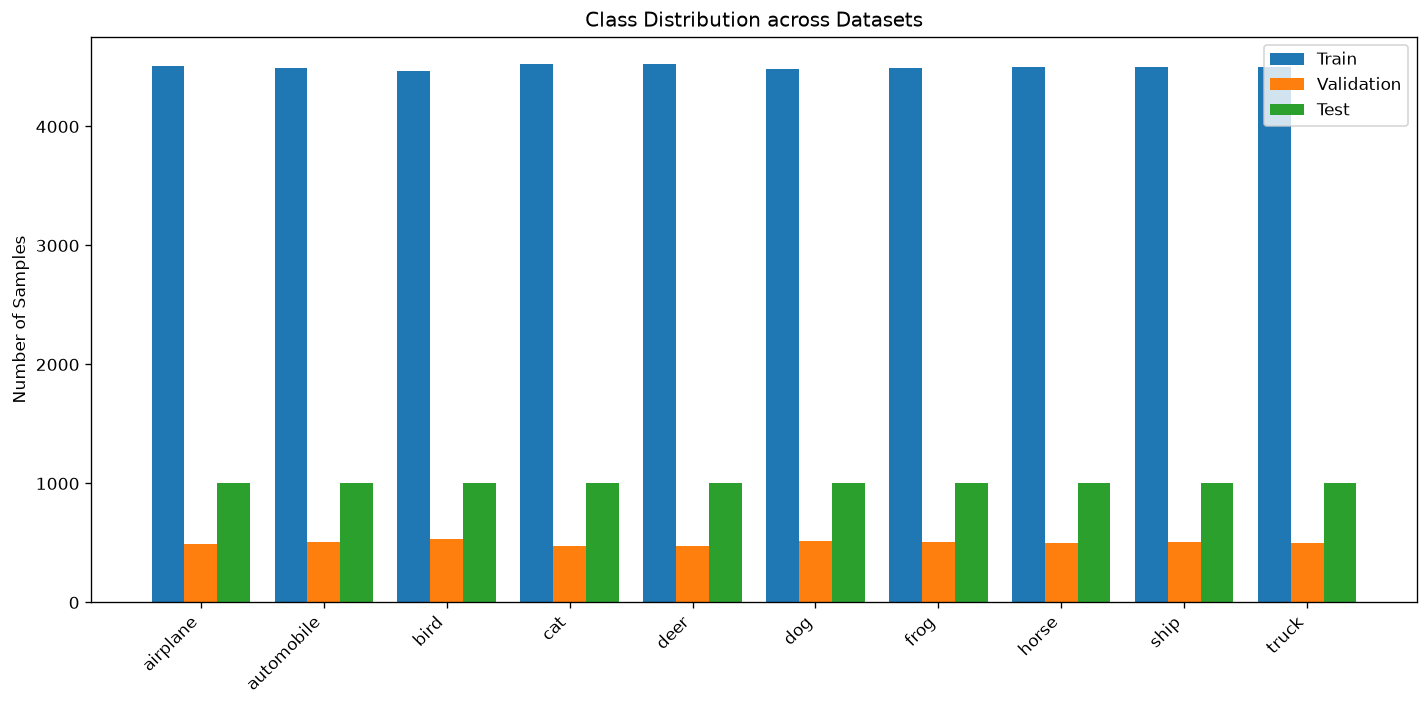

#### Representative CIFAR-10 samples

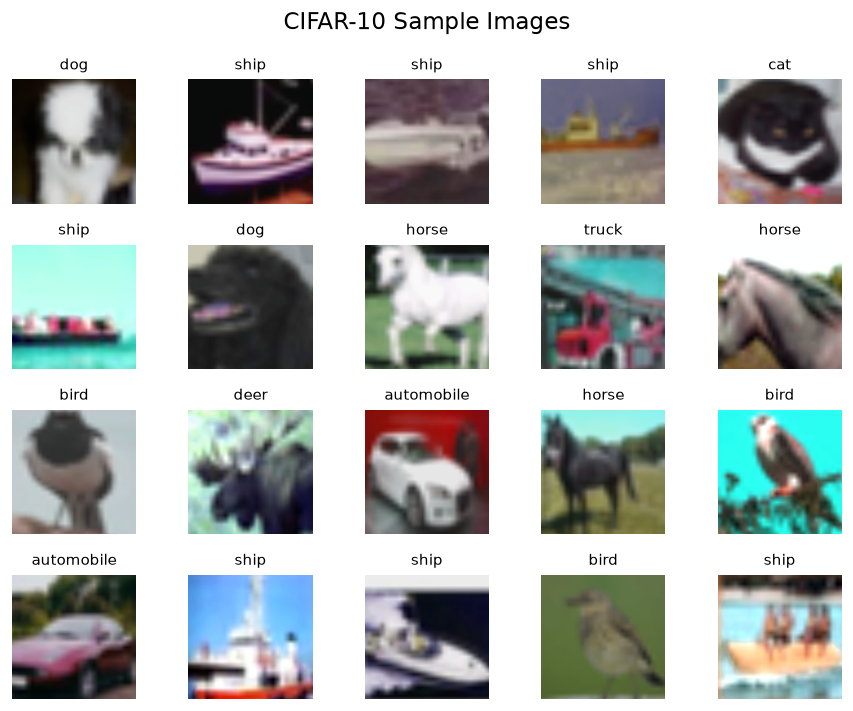

#### Examples from every CIFAR-10 class

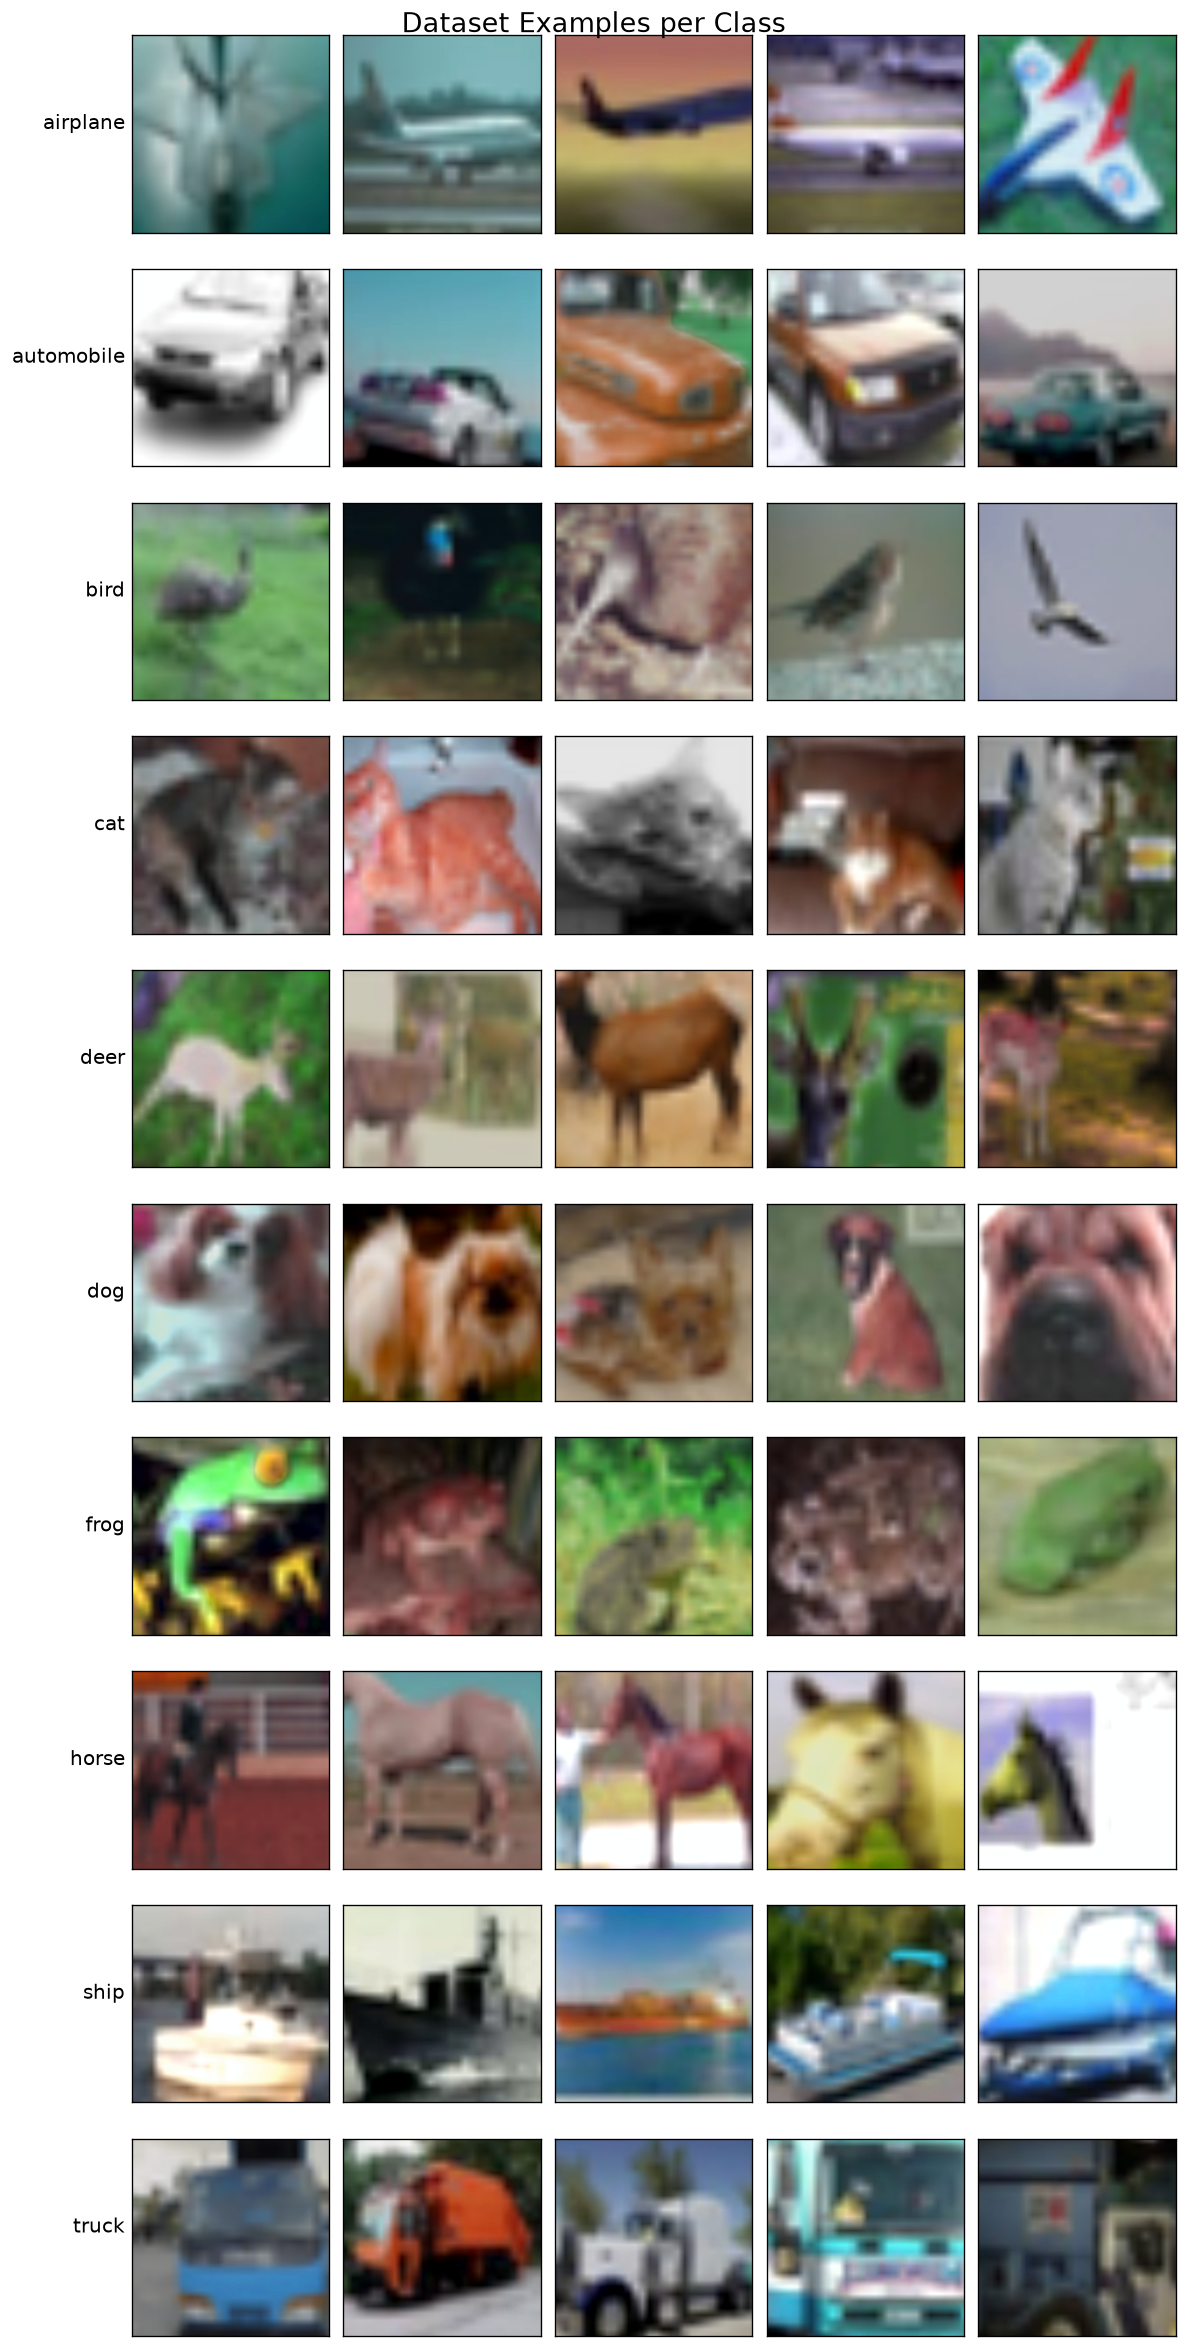

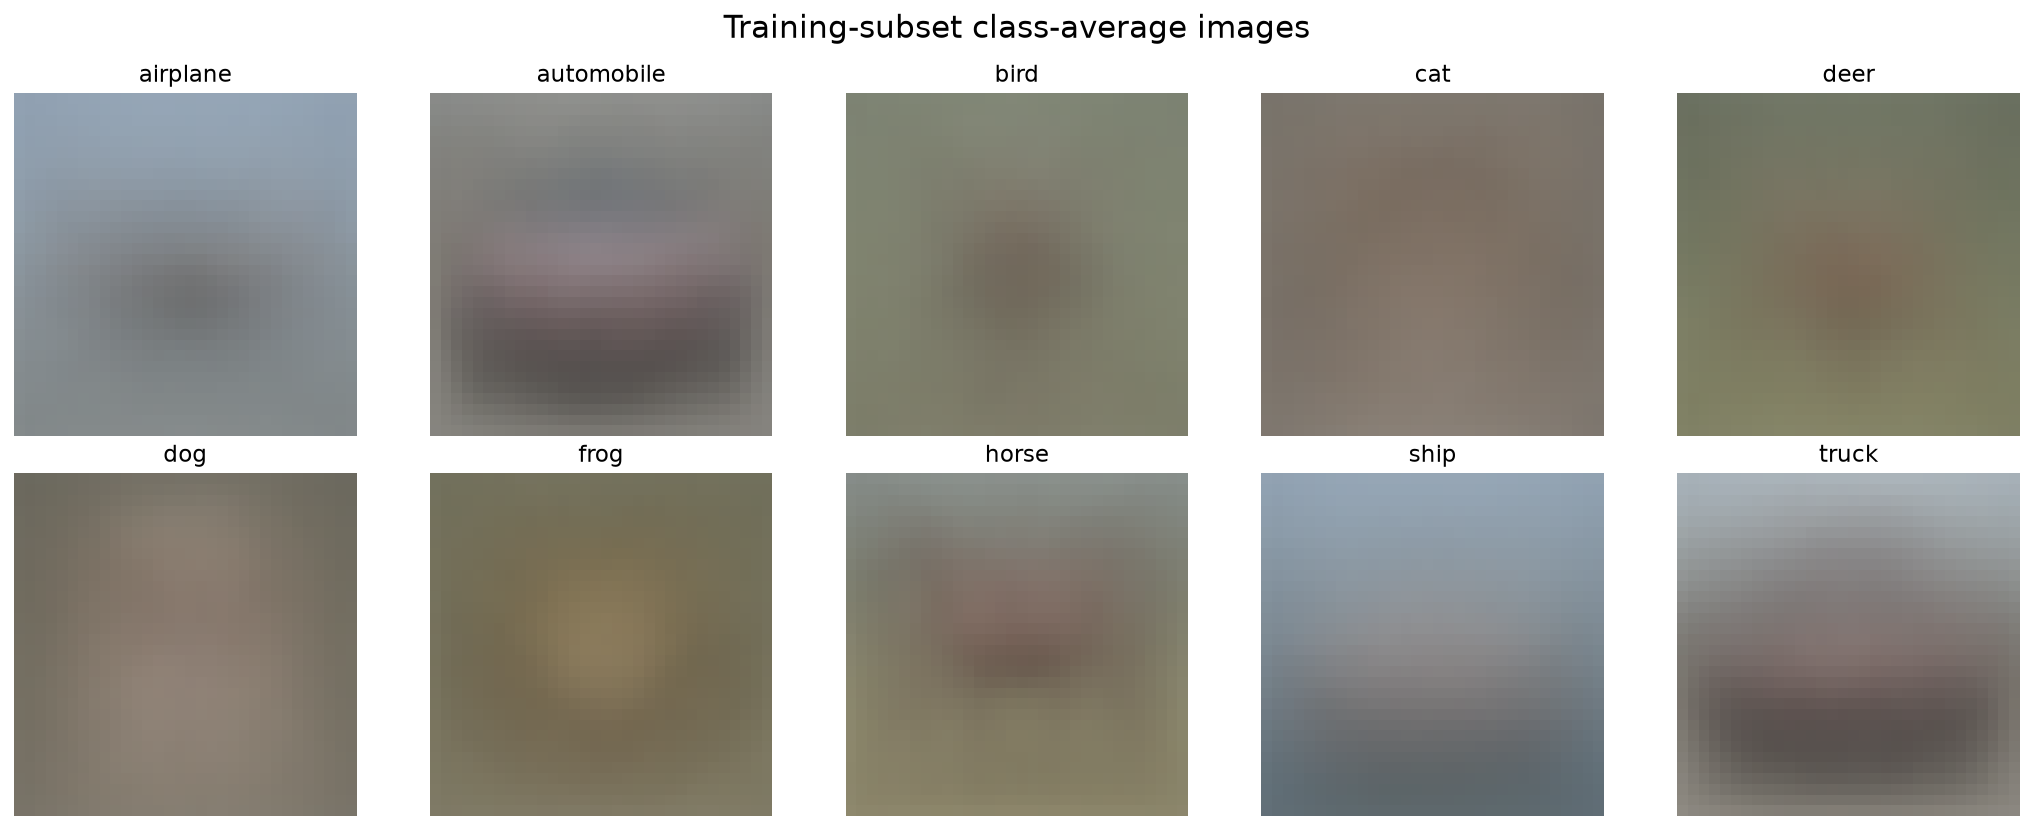

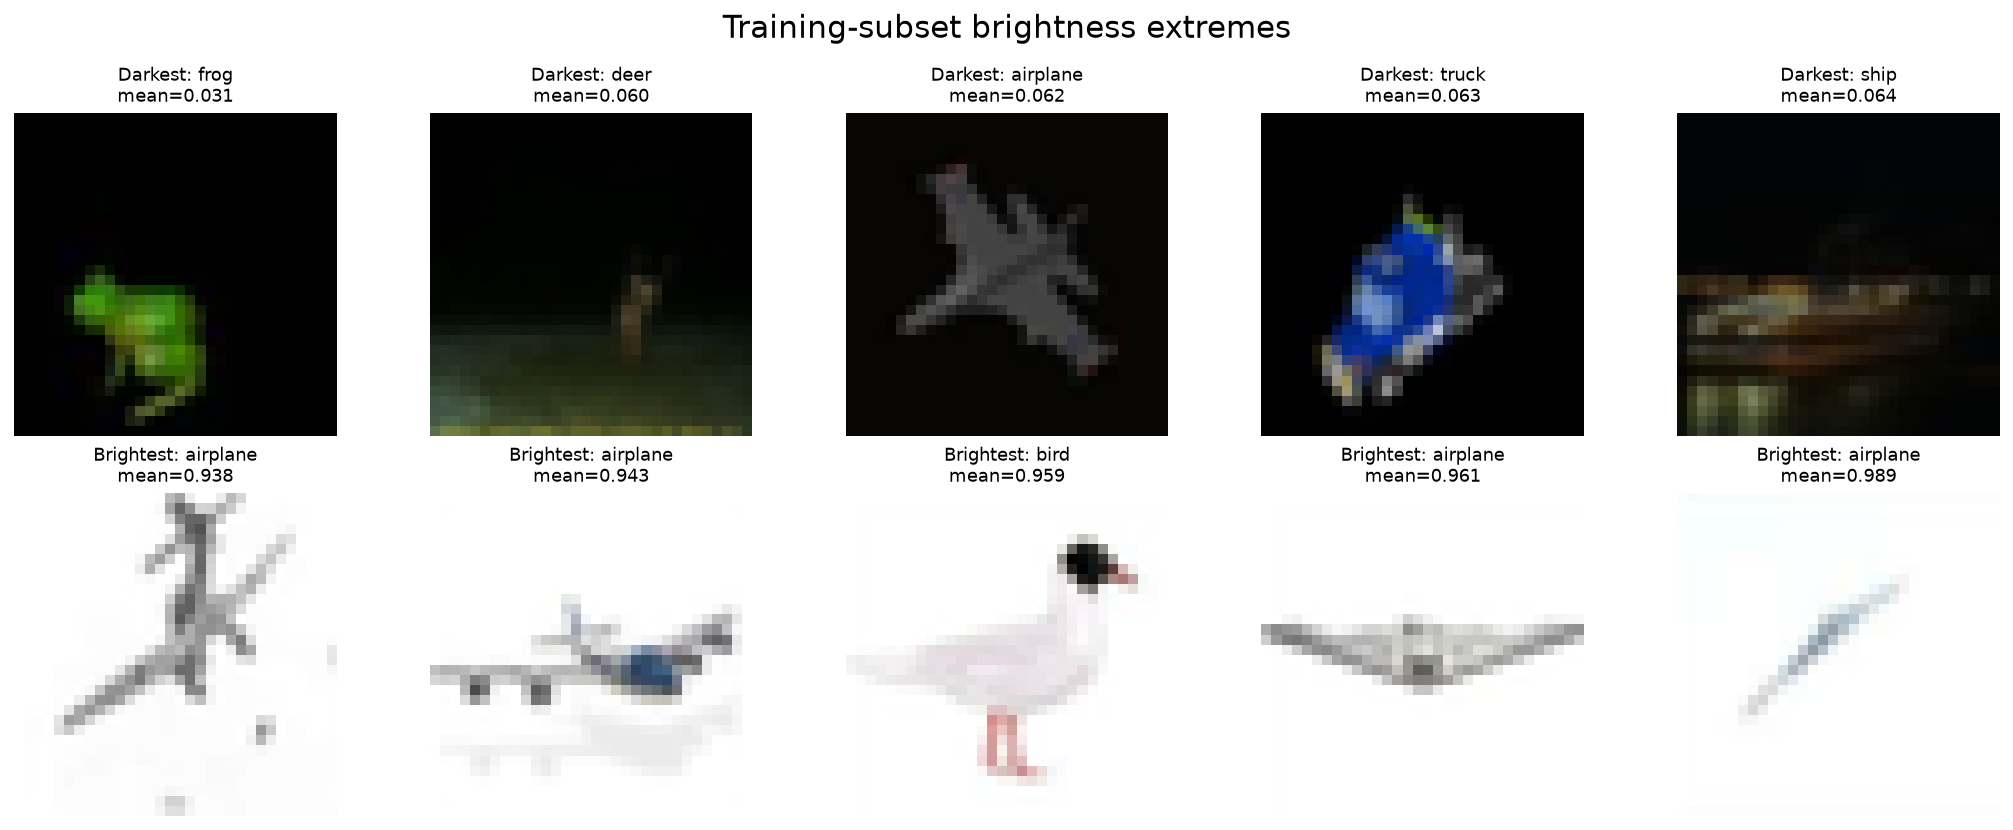

### Deterministic PCA and t-SNE projection

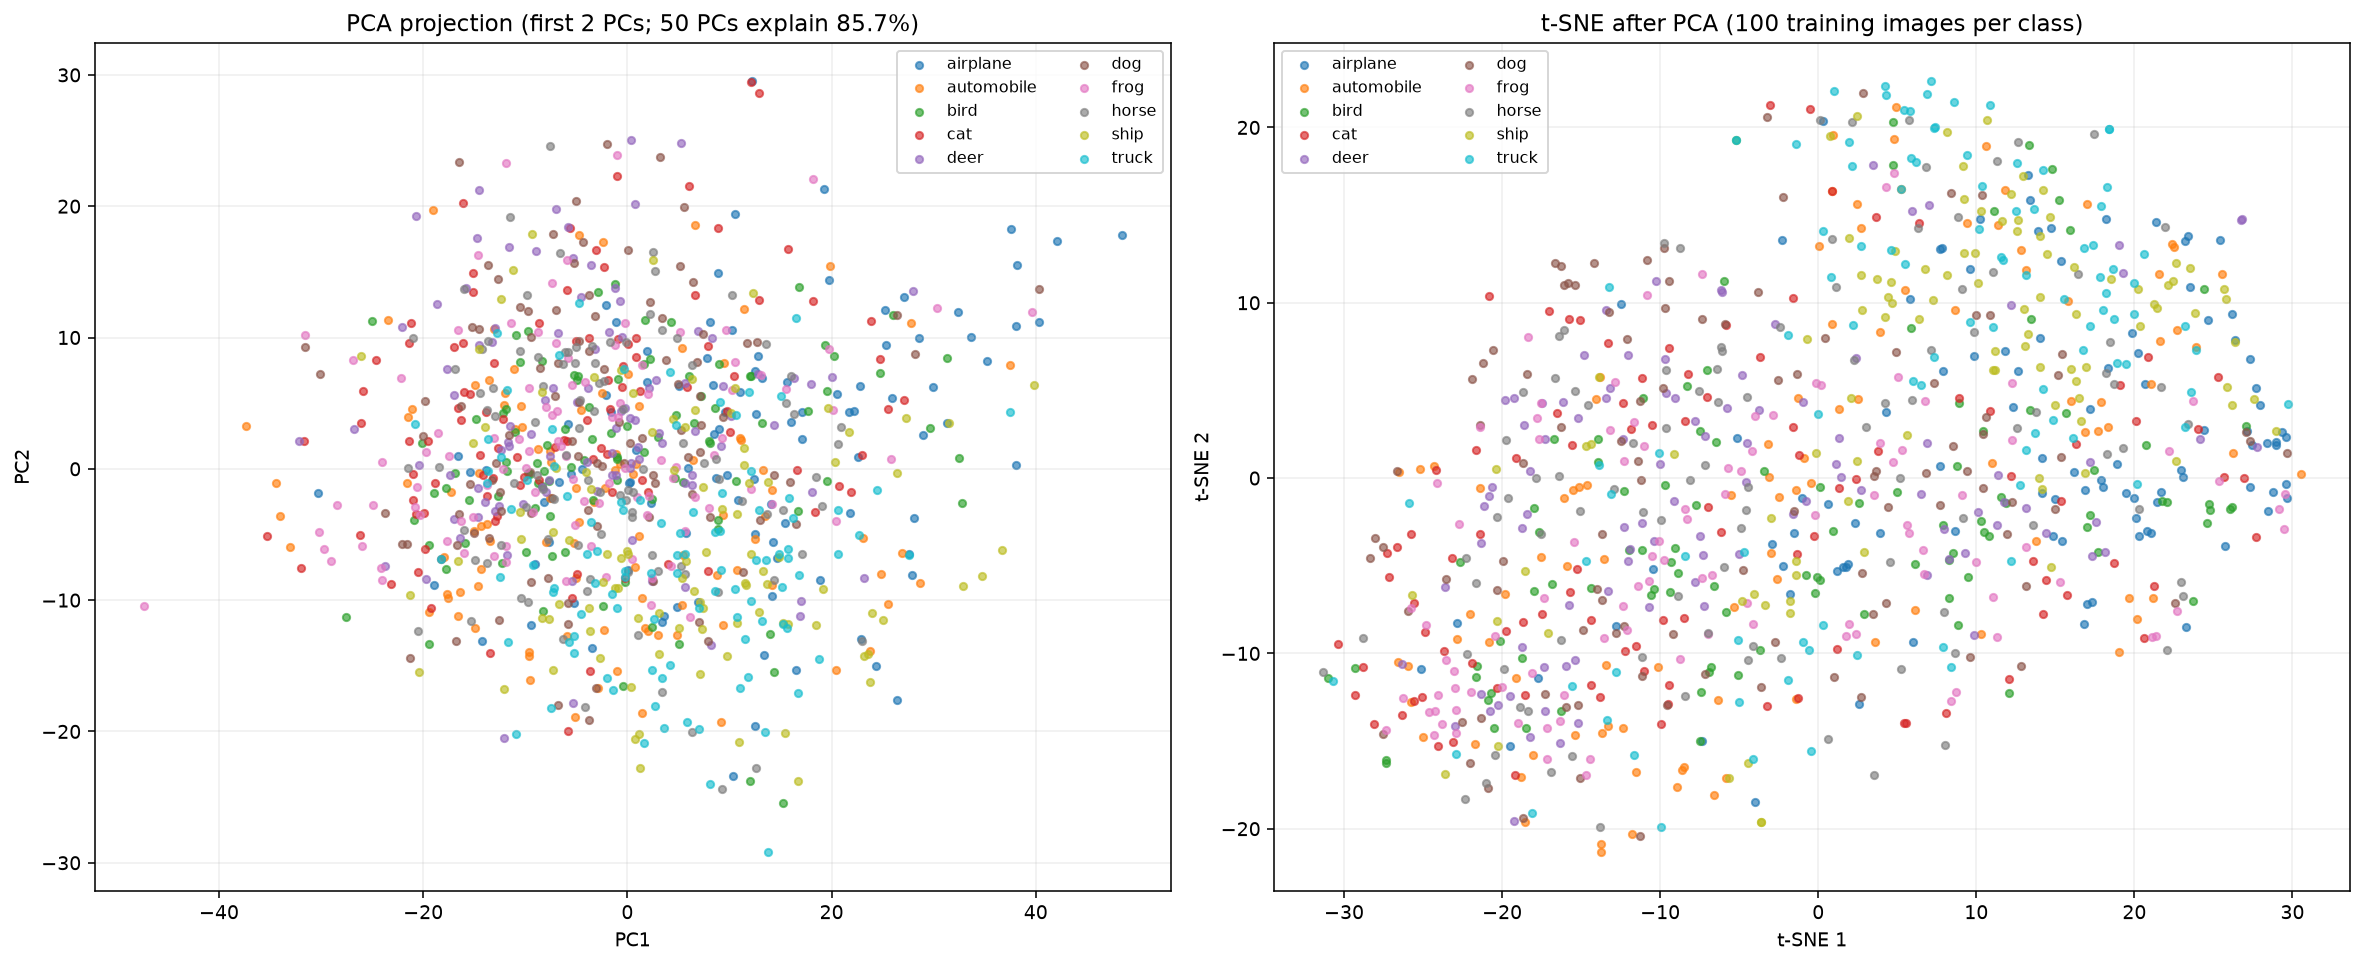

### EDA conclusions
- The training subset contains all ten classes with no invalid labels or conflicting-label exact duplicates.
- RGB intensity, brightness and contrast vary substantially, supporting augmentation and ImageNet-compatible normalization.
- Class-average images retain coarse silhouettes, while PCA/t-SNE overlap confirms that raw pixels do not linearly separate the semantic classes.
- Low resolution and overlapping animal classes motivate transfer learning and later class-level error analysis.
- These findings use Training pixels only and do not change the Validation-only selection protocol.

In [4]:
display(Markdown("### Representative samples, class means and statistical extremes"))
for filename, title in (
    ("class_distribution.png", "Class distribution across data splits"),
    ("data_samples.png", "Representative CIFAR-10 samples"),
    ("class_examples.png", "Examples from every CIFAR-10 class"),
):
    candidates = (OUTPUT_DIR / filename, REPORTS_DIR / filename)
    artifact_path = next((path for path in candidates if path.exists()), None)
    if artifact_path is not None:
        display(Markdown(f"#### {title}"))
        display(Image(filename=str(artifact_path)))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for class_index, ax in enumerate(axes.flat):
    ax.imshow(raw_train[train_labels == class_index].mean(axis=0).astype(np.uint8))
    ax.set_title(CLASS_NAMES[class_index])
    ax.axis("off")
fig.suptitle("Training-subset class-average images", fontsize=16)
fig.tight_layout()
class_means_path = REPORTS_DIR / "eda_class_mean_images.png"
fig.savefig(class_means_path, dpi=140, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(class_means_path)))

extreme_indices = np.r_[np.argsort(image_brightness)[:5], np.argsort(image_brightness)[-5:]]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for position, (ax, sample_index) in enumerate(zip(axes.flat, extreme_indices)):
    ax.imshow(raw_train[sample_index])
    group = "Darkest" if position < 5 else "Brightest"
    ax.set_title(f"{group}: {CLASS_NAMES[train_labels[sample_index]]}\nmean={image_brightness[sample_index]:.3f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Training-subset brightness extremes", fontsize=16)
fig.tight_layout()
outliers_path = REPORTS_DIR / "eda_brightness_extremes.png"
fig.savefig(outliers_path, dpi=140, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(outliers_path)))

display(Markdown("### Deterministic PCA and t-SNE projection"))
projection_rng = np.random.default_rng(CONFIG["seed"])
projection_indices = np.concatenate([
    projection_rng.choice(np.flatnonzero(train_labels == class_index), size=100, replace=False)
    for class_index in range(len(CLASS_NAMES))
])
projection_features = train_float[projection_indices, ::2, ::2, :].reshape(len(projection_indices), -1)
projection_features = StandardScaler().fit_transform(projection_features)
pca = PCA(n_components=50, svd_solver="randomized", random_state=CONFIG["seed"])
pca_features = pca.fit_transform(projection_features)
tsne_features = TSNE(
    n_components=2, perplexity=30, learning_rate="auto", max_iter=750,
    init="pca", random_state=CONFIG["seed"],
).fit_transform(pca_features)
projection_labels = train_labels[projection_indices]
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for class_index, class_name in enumerate(CLASS_NAMES):
    mask = projection_labels == class_index
    axes[0].scatter(pca_features[mask, 0], pca_features[mask, 1], s=14, alpha=0.65, label=class_name)
    axes[1].scatter(tsne_features[mask, 0], tsne_features[mask, 1], s=14, alpha=0.65, label=class_name)
axes[0].set(title=f"PCA projection (first 2 PCs; 50 PCs explain {pca.explained_variance_ratio_.sum():.1%})", xlabel="PC1", ylabel="PC2")
axes[1].set(title="t-SNE after PCA (100 training images per class)", xlabel="t-SNE 1", ylabel="t-SNE 2")
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
projection_path = REPORTS_DIR / "eda_pca_tsne.png"
fig.savefig(projection_path, dpi=140, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(projection_path)))

display(Markdown(
    "### EDA conclusions\n"
    "- The training subset contains all ten classes with no invalid labels or conflicting-label exact duplicates.\n"
    "- RGB intensity, brightness and contrast vary substantially, supporting augmentation and ImageNet-compatible normalization.\n"
    "- Class-average images retain coarse silhouettes, while PCA/t-SNE overlap confirms that raw pixels do not linearly separate the semantic classes.\n"
    "- Low resolution and overlapping animal classes motivate transfer learning and later class-level error analysis.\n"
    "- These findings use Training pixels only and do not change the Validation-only selection protocol."
))

## Phase 5 - Data Preprocessing

The pretrained backbones were optimized on ImageNet. Practice 2 therefore follows the expected ImageNet input convention instead of fitting a new scaler on CIFAR-10.

```text
CIFAR-10 image (32 × 32 RGB)
        ↓
Resize to approximately 255 × 255
        ↓
Random crop for train / center crop for validation and test
        ↓
224 × 224 tensor
        ↓
ImageNet mean/std normalization
```

The random operations belong only to the training transform. Applying them to validation or test would make metrics noisy and irreproducible.

In [5]:
train_transform = train_subset.dataset.transform
validation_transform = val_subset.dataset.transform
test_transform = test_dataset.transform

train_transform_text = repr(train_transform)
validation_transform_text = repr(validation_transform)
test_transform_text = repr(test_transform)

assert train_subset.dataset is not val_subset.dataset
assert "RandomCrop" in train_transform_text
assert "RandomHorizontalFlip" in train_transform_text
assert "ColorJitter" in train_transform_text
assert "RandomCrop" not in validation_transform_text
assert "RandomHorizontalFlip" not in validation_transform_text
assert "ColorJitter" not in validation_transform_text
assert "CenterCrop" in validation_transform_text
assert validation_transform_text == test_transform_text

preprocessing_summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "crop": ["RandomCrop", "CenterCrop", "CenterCrop"],
        "horizontal_flip": [True, False, False],
        "color_jitter": [True, False, False],
        "deterministic": [False, True, True],
        "normalization": ["ImageNet", "ImageNet", "ImageNet"],
    }
)
display(Markdown(
    "Preprocessing is attached after the split is fixed. Only Train receives "
    "random augmentation; Validation and Test share the same deterministic transform."
))
display(colored_table(
    preprocessing_summary,
    "Preprocessing by data split",
    boolean_columns=["horizontal_flip", "color_jitter", "deterministic"],
))

print("Training transform:\n", train_transform)
print("\nValidation/Test transform:\n", validation_transform)

Preprocessing is attached after the split is fixed. Only Train receives random augmentation; Validation and Test share the same deterministic transform.

,split,crop,horizontal_flip,color_jitter,deterministic,normalization
0,Train,RandomCrop,True,True,False,ImageNet
1,Validation,CenterCrop,False,False,True,ImageNet
2,Test,CenterCrop,False,False,True,ImageNet


Training transform:
 Compose(
    Resize(size=(255, 255), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transform:
 Compose(
    Resize(size=(255, 255), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Phase 6 - Model Building and Baseline

A baseline is required before interpreting a more complex fine-tuning strategy.

| Baseline | Expected/observed role |
|---|---|
| Random guessing | Approximately 10% accuracy for ten balanced classes |
| Majority-class predictor | Approximately 10% because CIFAR-10 is balanced |
| ResNet18 head-only | Transfer-learning baseline: frozen feature extractor, trainable classifier only |

The head-only ResNet18 experiment is the meaningful implementation baseline for this assignment because the objective specifically concerns pretrained neural networks.

In [6]:
from processing_own_phase.model import build_model

baseline_model = build_model("resnet18", training_mode="head_only")
total_parameters = sum(parameter.numel() for parameter in baseline_model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
    if parameter.requires_grad
)

baseline_summary = pd.DataFrame(
    {
        "item": ["Model", "Strategy", "Total parameters", "Trainable parameters", "Random baseline"],
        "value": ["ResNet18", "head_only", total_parameters, trainable_parameters, "10%"],
    }
)
display(colored_table(baseline_summary, "Baseline model summary"))

,item,value
0,Model,ResNet18
1,Strategy,head_only
2,Total parameters,11181642
3,Trainable parameters,5130
4,Random baseline,10%


## Phase 7 - Model Training

Training is implemented in reusable source modules rather than duplicated in the notebook. Every run uses label-smoothed `CrossEntropyLoss`, AdamW, Warmup-Cosine scheduling, gradient clipping, TensorBoard, durable `metrics.jsonl` logging, and dual checkpoint management.

The approved search uses ResNet18 `partial_finetune` and compares three learning-rate pairs followed by three classifier heads:

| Search stage | Candidates |
|---|---|
| Learning rate | `3e-4/3e-5`, `6e-4/6e-5`, `1e-3/1e-4` (head/backbone) |
| Classifier head | Linear, `[256]`, `[256, 128]` |

Each run has a maximum of 25 epochs and Early Stopping patience 4. Minimum Validation loss selects `best_val_loss.pt`; Validation accuracy is the tie-breaker. The separate `live_training_monitor.py` dashboard reads `metrics.jsonl` without touching Train, Validation, Test, or model state.

,rank,stage,candidate,epochs_trained,best_epoch,best_val_loss,best_val_accuracy
0,1,learning_rate,lr_current,25,24,0.430360,0.944200
1,2,classifier_head,linear,25,24,0.430360,0.944200
2,3,learning_rate,lr_mid,25,24,0.440741,0.945600
3,4,learning_rate,lr_low,25,24,0.462627,0.939800
4,5,classifier_head,mlp_2,25,24,0.467199,0.944600
5,6,classifier_head,mlp_1,9,5,0.489788,0.930000


### Winning run — complete training-log dashboard

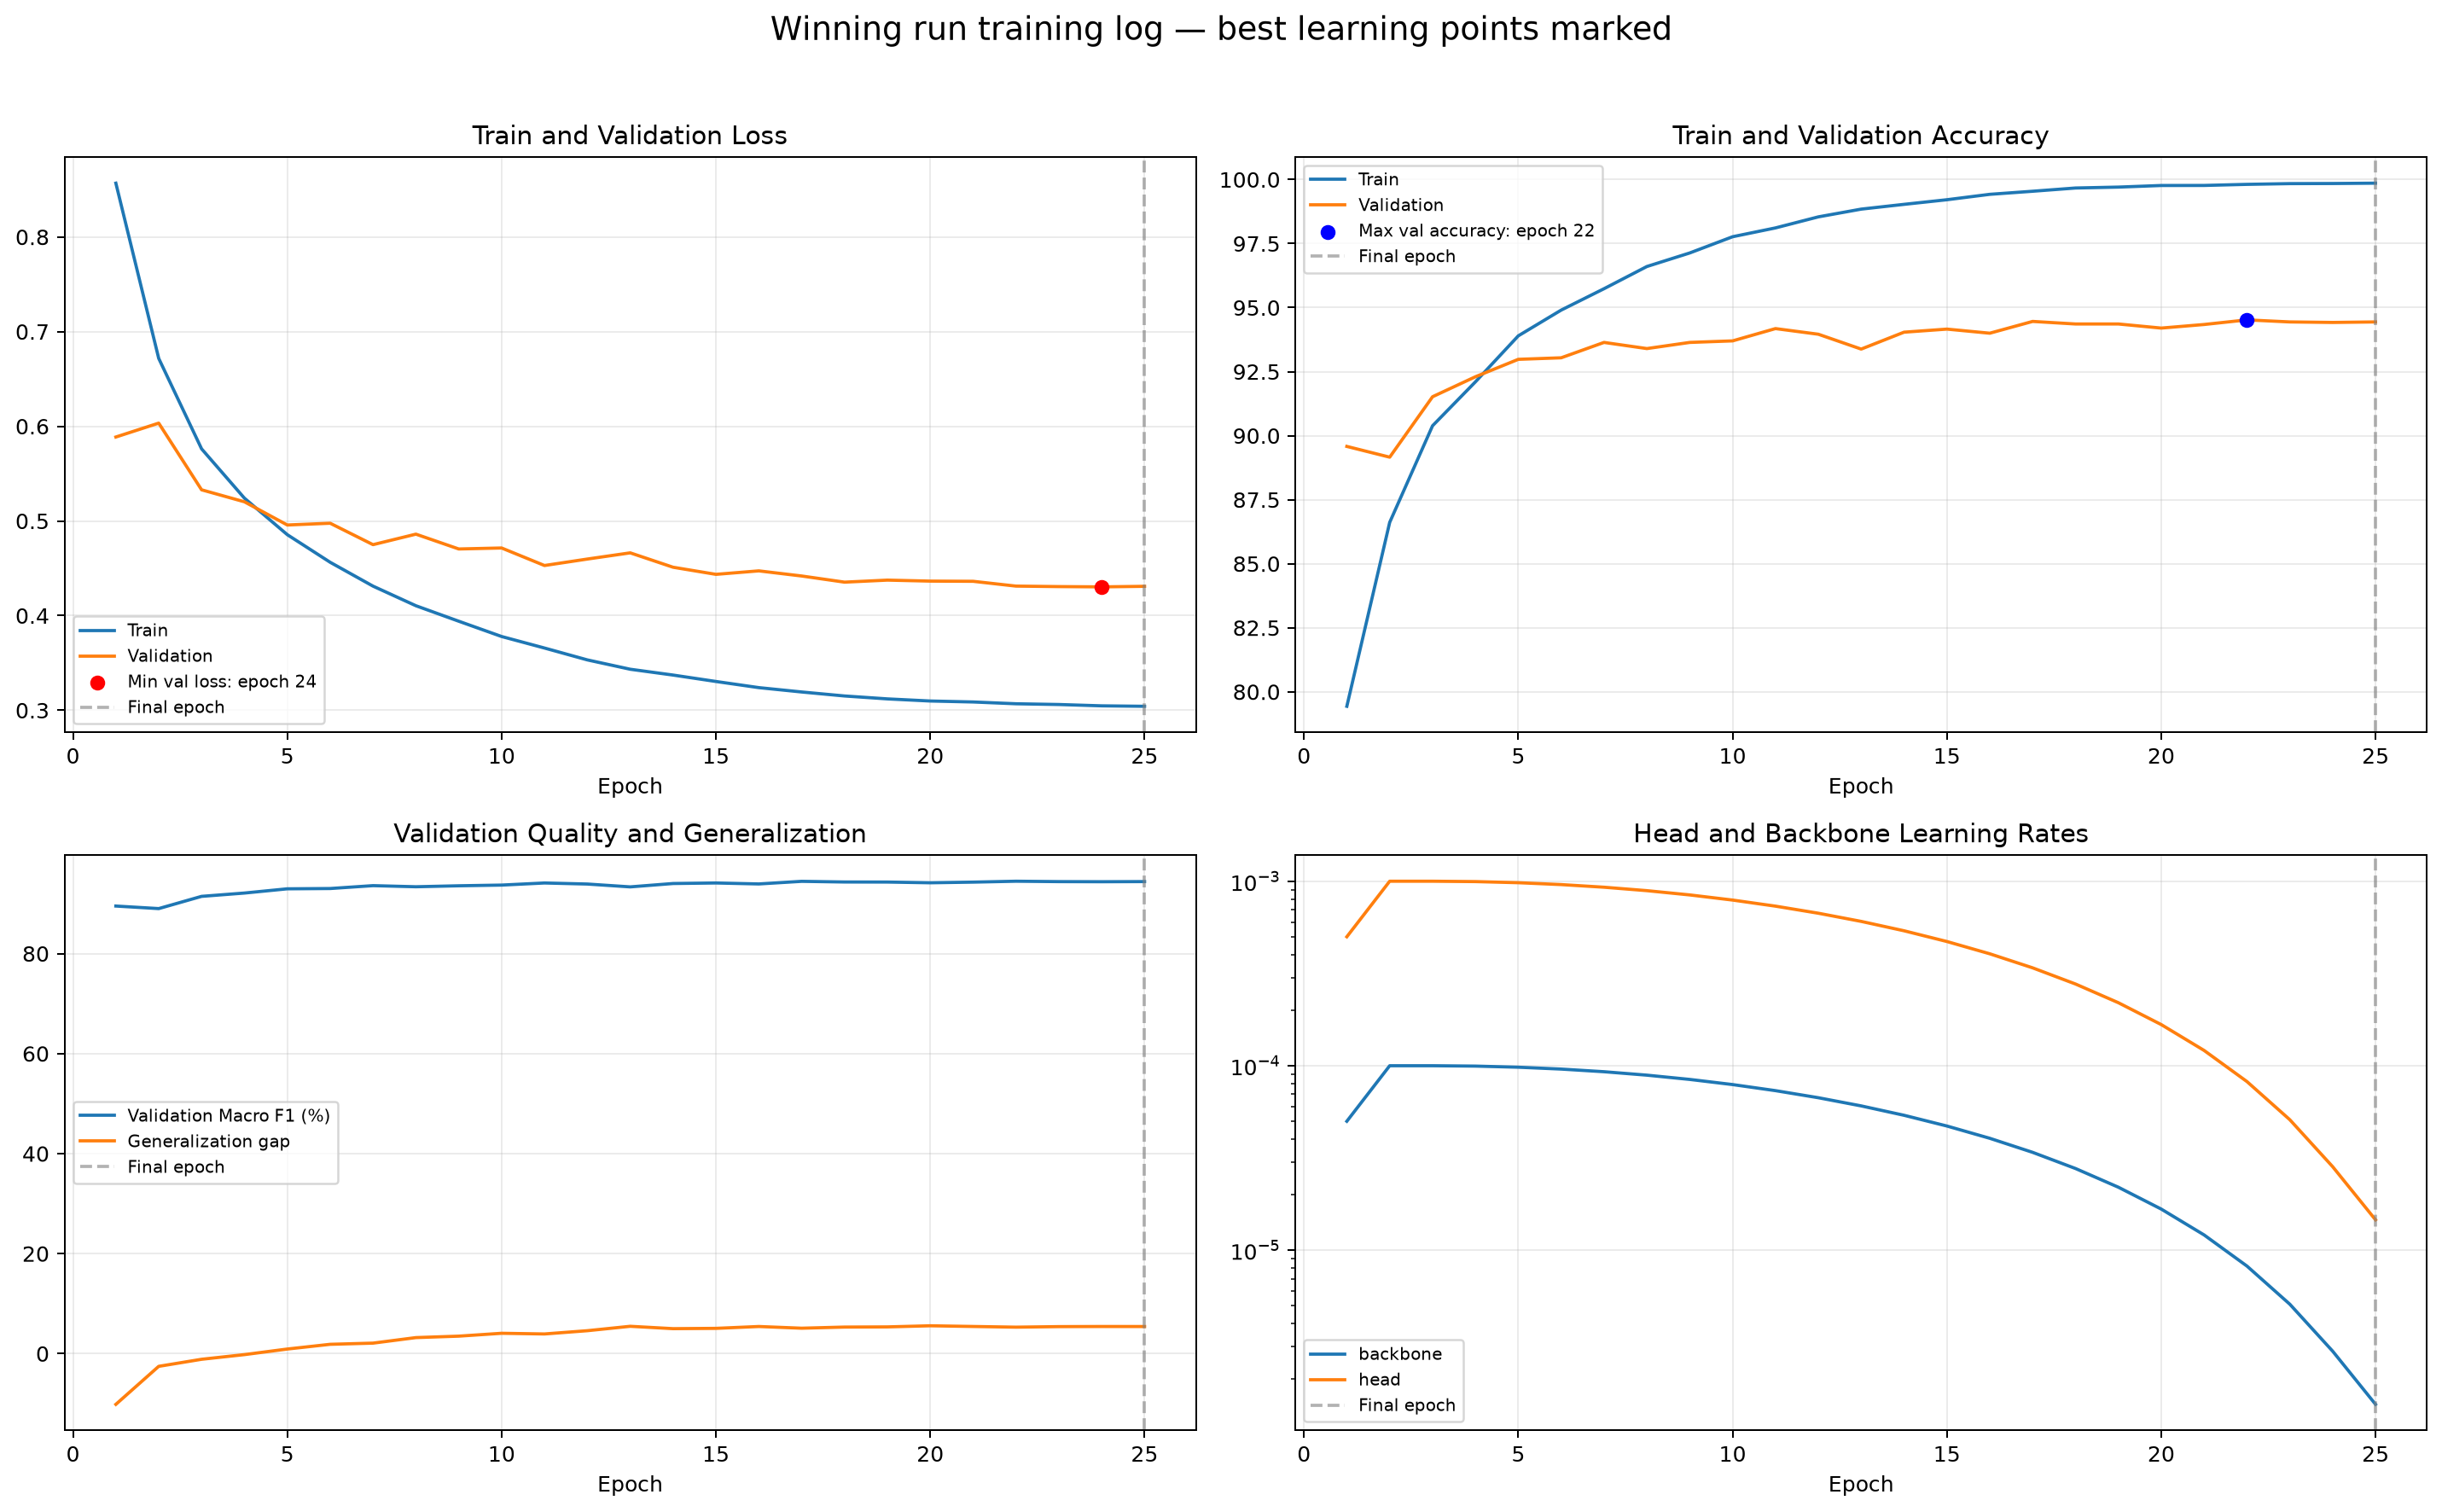

Dashboard artifact: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/reports/winner_training_log_dashboard.png


In [7]:
ranking_path = OUTPUT_DIR / "hyperparameter_ranking.csv"
selection_path = OUTPUT_DIR / "hyperparameter_selection_locked.json"
ranking = pd.read_csv(ranking_path)
selection = json.loads(selection_path.read_text())
assert len(ranking) == 6 and selection["status"] == "LOCKED_VALIDATION_ONLY"
display(colored_table(
    ranking[["rank", "stage", "candidate", "epochs_trained", "best_epoch", "best_val_loss", "best_val_accuracy"]],
    "Completed multi-epoch hyperparameter runs — Validation only",
    gradient_columns=["epochs_trained", "best_epoch", "best_val_loss", "best_val_accuracy"],
))
winner_metrics = pd.read_json(
    Path(selection["selected_checkpoint"]).parent / "metrics.jsonl", lines=True
)
best_loss_row = winner_metrics.loc[winner_metrics["val_loss"].idxmin()]
best_acc_row = winner_metrics.loc[winner_metrics["val_accuracy"].idxmax()]
last_epoch = int(winner_metrics["epoch"].iloc[-1])
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(winner_metrics["epoch"], winner_metrics["train_loss"], label="Train")
axes[0, 0].plot(winner_metrics["epoch"], winner_metrics["val_loss"], label="Validation")
axes[0, 0].scatter(best_loss_row["epoch"], best_loss_row["val_loss"], color="red", zorder=5, label=f"Min val loss: epoch {int(best_loss_row['epoch'])}")
axes[0, 0].set_title("Train and Validation Loss")
axes[0, 1].plot(winner_metrics["epoch"], winner_metrics["train_accuracy"], label="Train")
axes[0, 1].plot(winner_metrics["epoch"], winner_metrics["val_accuracy"], label="Validation")
axes[0, 1].scatter(best_acc_row["epoch"], best_acc_row["val_accuracy"], color="blue", zorder=5, label=f"Max val accuracy: epoch {int(best_acc_row['epoch'])}")
axes[0, 1].set_title("Train and Validation Accuracy")
axes[1, 0].plot(winner_metrics["epoch"], 100 * winner_metrics["val_macro_f1"], label="Validation Macro F1 (%)")
axes[1, 0].plot(winner_metrics["epoch"], winner_metrics["generalization_gap"], label="Generalization gap")
axes[1, 0].set_title("Validation Quality and Generalization")
learning_rates = pd.json_normalize(winner_metrics["learning_rates"])
for column in learning_rates.columns:
    axes[1, 1].plot(winner_metrics["epoch"], learning_rates[column], label=column)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Head and Backbone Learning Rates")
for ax in axes.flat:
    ax.axvline(last_epoch, color="gray", linestyle="--", alpha=0.6, label="Final epoch")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle("Winning run training log — best learning points marked", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.96))
training_dashboard_path = REPORTS_DIR / "winner_training_log_dashboard.png"
fig.savefig(training_dashboard_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(Markdown("### Winning run — complete training-log dashboard"))
display(Image(filename=str(training_dashboard_path), width=1400))
print(f"Dashboard artifact: {training_dashboard_path}")

## Phase 8 - Validation-only Hyperparameter Search

The official comparison contains six ResNet18 partial-fine-tuning runs. Stage 1 varies only the head/backbone learning-rate pair. Stage 2 fixes the winning learning rate and varies only classifier-head depth.

Therefore:

- Three learning-rate pairs are compared first.
- Linear, one-hidden-layer and two-hidden-layer heads are compared second.
- All other training settings, data split and seed remain fixed within each stage.
- Test data is excluded from experiment selection.
- Primary selection is minimum Validation loss; maximum Validation accuracy is the tie-breaker.

In [8]:
lr_trials = ranking[ranking["stage"] == "learning_rate"]
head_trials = ranking[ranking["stage"] == "classifier_head"]
assert len(lr_trials) == 3 and len(head_trials) == 3
display(colored_table(lr_trials, "Learning-rate search", gradient_columns=["best_val_loss", "best_val_accuracy"]))
display(colored_table(head_trials, "Classifier-head search", gradient_columns=["best_val_loss", "best_val_accuracy"]))
print("All comparisons use Validation only; Test was locked during search.")

,rank,stage,candidate,run_id,head_learning_rate,backbone_learning_rate,hidden_layers,best_epoch,epochs_trained,best_val_loss,best_val_accuracy,val_macro_f1_at_selected_checkpoint,training_seconds,checkpoint,test_data_used
0,1,learning_rate,lr_current,E2_resnet18_partial_2b5b94de,0.001000,0.000100,[],24,25,0.430360,0.944200,0.943684,2811.303865,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_2b5b94de/best_val_loss.pt,False
2,3,learning_rate,lr_mid,E2_resnet18_partial_d4803984,0.000600,0.000060,[],24,25,0.440741,0.945600,0.945161,2849.569697,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_d4803984/best_val_loss.pt,False
3,4,learning_rate,lr_low,E2_resnet18_partial_e70fbda1,0.000300,0.000030,[],24,25,0.462627,0.939800,0.939163,2872.021255,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_e70fbda1/best_val_loss.pt,False


,rank,stage,candidate,run_id,head_learning_rate,backbone_learning_rate,hidden_layers,best_epoch,epochs_trained,best_val_loss,best_val_accuracy,val_macro_f1_at_selected_checkpoint,training_seconds,checkpoint,test_data_used
1,2,classifier_head,linear,E2_resnet18_partial_a950431a,0.001000,0.000100,[],24,25,0.430360,0.944200,0.943684,2811.065401,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_a950431a/best_val_loss.pt,False
4,5,classifier_head,mlp_2,E2_resnet18_partial_f9ddc639,0.001000,0.000100,"[256, 128]",24,25,0.467199,0.944600,0.944210,2823.873975,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_f9ddc639/best_val_loss.pt,False
5,6,classifier_head,mlp_1,E2_resnet18_partial_0f4f28e0,0.001000,0.000100,[256],5,9,0.489788,0.930000,0.929207,1014.664127,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_0f4f28e0/best_val_loss.pt,False


All comparisons use Validation only; Test was locked during search.


## Phase 9 - Model Selection and Checkpoint Verification

Internal metric values use the `[0, 1]` convention. Multiplication by 100 happens only in the presentation layer.

The ranking below is generated from six completed multi-epoch runs. The winner is selected only by minimum Validation loss, with Validation accuracy as tie-breaker. Test metrics are forbidden in this phase.

In [9]:
comparison_path = OUTPUT_DIR / "hyperparameter_ranking.csv"
selection_path = OUTPUT_DIR / "hyperparameter_selection_locked.json"
if not comparison_path.exists():
    raise FileNotFoundError(
        "hyperparameter_ranking.csv is required. Run the search first."
    )

comparison = pd.read_csv(comparison_path)
selection = json.loads(selection_path.read_text())
required_columns = ["rank", "stage", "candidate", "run_id", "epochs_trained", "best_epoch", "best_val_accuracy", "best_val_loss", "val_macro_f1_at_selected_checkpoint", "training_seconds"]
assert set(required_columns).issubset(comparison.columns)
assert comparison["test_data_used"].eq(False).all()
assert selection["selection_metric"] == "val_loss"
assert selection["selection_source"] == "validation_only"
assert selection["test_data_used"] is False

comparison = comparison.sort_values(["best_val_loss", "best_val_accuracy"], ascending=[True, False]).reset_index(drop=True)
display(colored_table(
    comparison,
    "Hyperparameter ranking — Validation only",
    gradient_columns=[
        "epochs_trained", "best_epoch", "best_val_accuracy",
        "best_val_loss", "val_macro_f1_at_selected_checkpoint", "training_seconds",
    ],
))

selected_experiment = selection["selected_experiment"]
expected_selection = comparison.iloc[0]["run_id"]
assert selected_experiment == expected_selection
print(f"Selected experiment: {selected_experiment}")
print(f"Best validation accuracy: {selection['best_val_accuracy']:.2%}")
print("Selection source: Validation only; the Test loader was not accessed.")

display(Markdown("### Winning configuration"))
display(pd.DataFrame([{key: selection[key] for key in ["head_learning_rate", "backbone_learning_rate", "hidden_layers", "best_epoch", "best_val_loss", "best_val_accuracy", "checkpoint_sha256"]}]))

,rank,stage,candidate,run_id,head_learning_rate,backbone_learning_rate,hidden_layers,best_epoch,epochs_trained,best_val_loss,best_val_accuracy,val_macro_f1_at_selected_checkpoint,training_seconds,checkpoint,test_data_used
0,1,learning_rate,lr_current,E2_resnet18_partial_2b5b94de,0.001000,0.000100,[],24,25,0.430360,0.944200,0.943684,2811.303865,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_2b5b94de/best_val_loss.pt,False
1,2,classifier_head,linear,E2_resnet18_partial_a950431a,0.001000,0.000100,[],24,25,0.430360,0.944200,0.943684,2811.065401,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_a950431a/best_val_loss.pt,False
2,3,learning_rate,lr_mid,E2_resnet18_partial_d4803984,0.000600,0.000060,[],24,25,0.440741,0.945600,0.945161,2849.569697,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_d4803984/best_val_loss.pt,False
3,4,learning_rate,lr_low,E2_resnet18_partial_e70fbda1,0.000300,0.000030,[],24,25,0.462627,0.939800,0.939163,2872.021255,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_e70fbda1/best_val_loss.pt,False
4,5,classifier_head,mlp_2,E2_resnet18_partial_f9ddc639,0.001000,0.000100,"[256, 128]",24,25,0.467199,0.944600,0.944210,2823.873975,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_f9ddc639/best_val_loss.pt,False
5,6,classifier_head,mlp_1,E2_resnet18_partial_0f4f28e0,0.001000,0.000100,[256],5,9,0.489788,0.930000,0.929207,1014.664127,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_0f4f28e0/best_val_loss.pt,False


Selected experiment: E2_resnet18_partial_2b5b94de
Best validation accuracy: 94.42%
Selection source: Validation only; the Test loader was not accessed.


### Winning configuration

,head_learning_rate,backbone_learning_rate,hidden_layers,best_epoch,best_val_loss,best_val_accuracy,checkpoint_sha256
0,0.001,0.0001,[],24,0.43036,0.9442,a906600b717f94aa4cf40ca8504f1b82f6618b80cc6bf9...


### Checkpoint verification protocol

The original final-evaluation implementation rebuilt the selected architecture without proving that the Validation-selected checkpoint had been restored. Any metric produced by that invalid path is excluded from this notebook.

The corrected protocol is:

```text
Select winner using minimum validation loss
        ↓
Load winner best_val_loss.pt and verify SHA256
        ↓
Re-evaluate validation using the original criterion and require loss/accuracy agreement
        ↓
Evaluate the locked checkpoint on the official test set
```

Cell 21 reloads the checkpoint path recorded by the Validation-only selection artifact and performs Validation verification without accessing Test.

In [10]:
from processing_own_phase.final_evaluate import verify_selected_checkpoint

verification = verify_selected_checkpoint(
    selection_path=str(OUTPUT_DIR / "hyperparameter_selection_locked.json"),
)
assert verification["status"] == "PASS"
assert verification["selection_metric"] == "val_loss"
assert verification["selection_source"] == "validation_only"
assert verification["test_accessed"] is False
checkpoint_path = Path(verification["checkpoint"])
assert checkpoint_path.name == "best_val_loss.pt" and checkpoint_path.is_file()
locked_selection = json.loads((OUTPUT_DIR / "hyperparameter_selection_locked.json").read_text())
receipt_path = OUTPUT_DIR / f"final_test_receipt_{locked_selection['checkpoint_sha256'][:12]}.json"
final_test_receipt = json.loads(receipt_path.read_text())
assert final_test_receipt["status"] == "FINAL_TEST_COMPLETE"
assert final_test_receipt["test_evaluation_count"] == 1

verification_table = pd.DataFrame([
    {"Check": "Validation verification", "Value": verification["status"]},
    {"Check": "Selected experiment", "Value": verification["selected_experiment"]},
    {"Check": "Checkpoint", "Value": str(checkpoint_path)},
    {"Check": "Selection source", "Value": verification["selection_source"]},
    {"Check": "Recorded Validation Accuracy", "Value": f"{verification['recorded_val_accuracy']:.2%}"},
    {"Check": "Reloaded Validation Accuracy", "Value": f"{verification['verified_val_accuracy']:.2%}"},
    {"Check": "Validation delta", "Value": f"{verification['validation_delta']:.8f}"},
    {"Check": "Validation loss delta", "Value": f"{verification['validation_loss_delta']:.3e}"},
    {"Check": "Best epoch", "Value": locked_selection["best_epoch"]},
    {"Check": "Head / backbone LR", "Value": f"{locked_selection['head_learning_rate']} / {locked_selection['backbone_learning_rate']}"},
    {"Check": "Hidden layers", "Value": str(locked_selection["hidden_layers"])},
    {"Check": "Checkpoint SHA256", "Value": locked_selection["checkpoint_sha256"]},
    {"Check": "Final Test receipt", "Value": final_test_receipt["status"]},
    {"Check": "Test evaluation count", "Value": final_test_receipt["test_evaluation_count"]},
    {"Check": "Test accessed by this cell", "Value": verification["test_accessed"]},
])
display(colored_table(
    verification_table,
    "Checkpoint Verification — Validation only",
))

,Check,Value
0,Validation verification,PASS
1,Selected experiment,E2_resnet18_partial_2b5b94de
2,Checkpoint,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2/runs/E2_resnet18_partial_2b5b94de/best_val_loss.pt
3,Selection source,validation_only
4,Recorded Validation Accuracy,94.42%
5,Reloaded Validation Accuracy,94.42%
6,Validation delta,0.00000000
7,Validation loss delta,1.335e-09
8,Best epoch,24
9,Head / backbone LR,0.001 / 0.0001


## Phase 10 - Final Test Evaluation

The final metrics below are read directly from `summary.json`, which is created only after the Validation-selected checkpoint passes verification. The Final Test pipeline records and asserts exactly one Test evaluation pass.

,Metric,Value
0,Test Accuracy,94.06%
1,Test Loss,0.226486
2,Macro Precision,0.940558
3,Macro Recall,0.940600
4,Macro F1,0.940458
5,Test Samples,10000


### Locked One-vs-Rest ROC and Precision–Recall artifacts

,class,roc_auc,average_precision
0,airplane,0.997925,0.991008
1,automobile,0.998380,0.990898
2,bird,0.994745,0.976985
3,cat,0.988979,0.940698
4,deer,0.996188,0.978571
5,dog,0.992365,0.958204
6,frog,0.999030,0.992350
7,horse,0.998275,0.991256
8,ship,0.998599,0.991849
9,truck,0.998960,0.992312


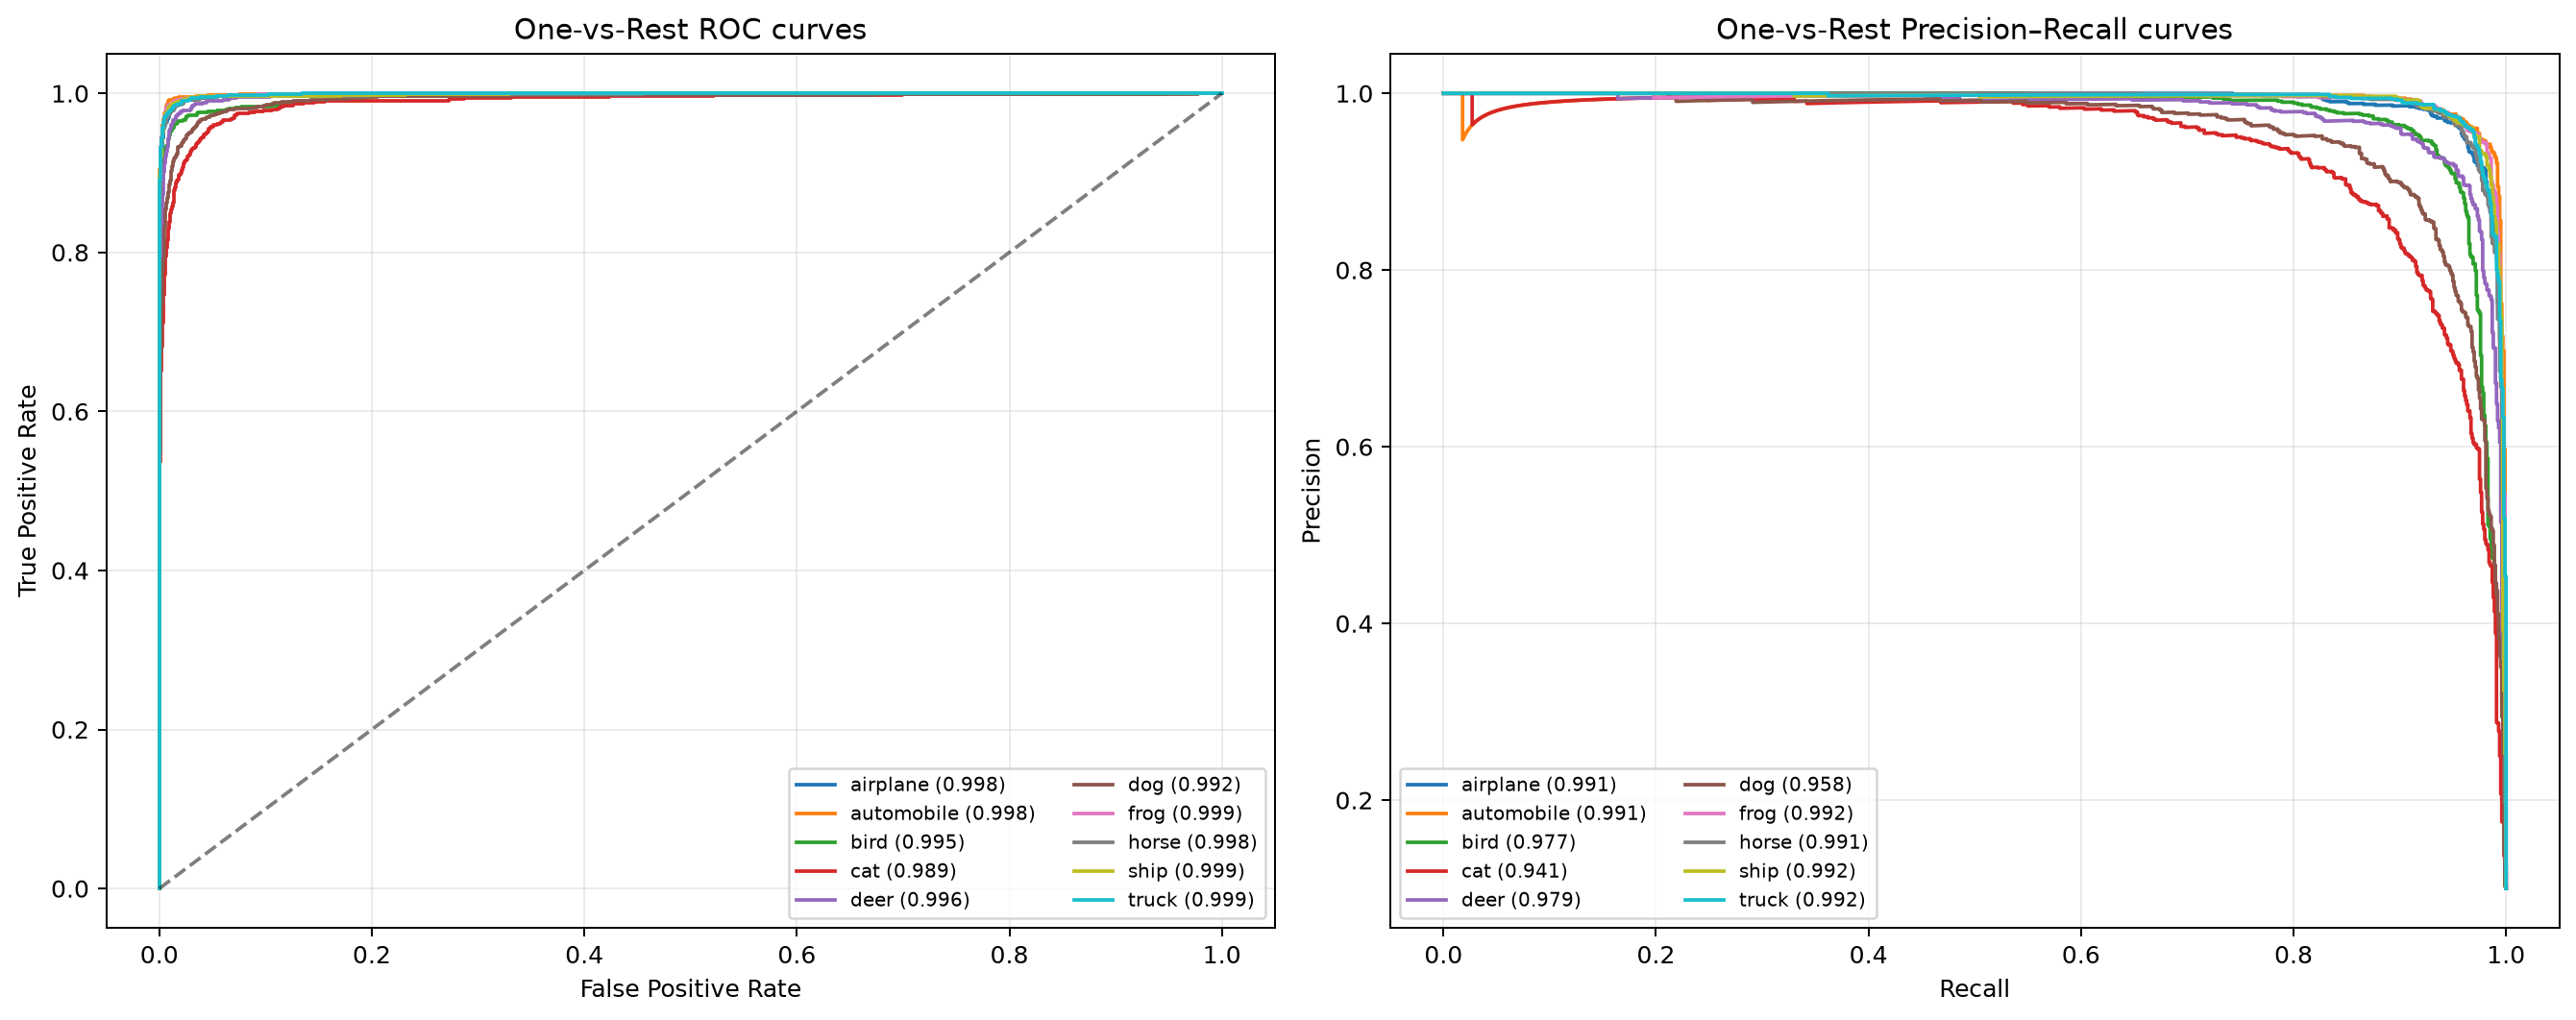

Confusion-matrix consistency: PASS | samples=10,000 | accuracy=94.06%


,True class,Predicted as,Count,Rate within true class
0,cat,dog,78,0.078000
1,dog,cat,50,0.050000
2,truck,automobile,30,0.030000
3,airplane,ship,25,0.025000
4,bird,deer,21,0.021000


### Validation–Test generalization from official artifacts

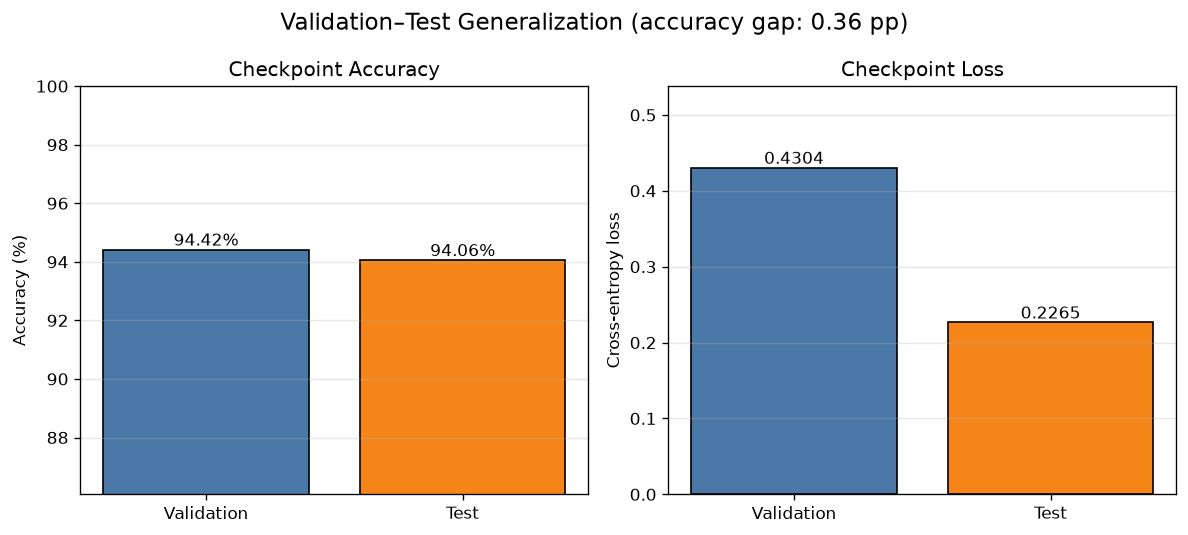

### Per-class classification report

,class,precision,recall,f1-score,support,TP,TN,FP,FN,TPR,FPR,class_accuracy
0,airplane,0.962437,0.948000,0.955164,1000,948,8963,37,52,0.948000,0.004111,0.991100
1,automobile,0.955882,0.975000,0.965347,1000,975,8955,45,25,0.975000,0.005000,0.993000
2,bird,0.949692,0.925000,0.937183,1000,925,8951,49,75,0.925000,0.005444,0.987600
3,cat,0.893194,0.853000,0.872634,1000,853,8898,102,147,0.853000,0.011333,0.975100
4,deer,0.918129,0.942000,0.929911,1000,942,8916,84,58,0.942000,0.009333,0.985800
5,dog,0.889216,0.907000,0.898020,1000,907,8887,113,93,0.907000,0.012556,0.979400
6,frog,0.952148,0.975000,0.963439,1000,975,8951,49,25,0.975000,0.005444,0.992600
7,horse,0.960566,0.950000,0.955254,1000,950,8961,39,50,0.950000,0.004333,0.991100
8,ship,0.958457,0.969000,0.963700,1000,969,8958,42,31,0.969000,0.004667,0.992700
9,truck,0.965863,0.962000,0.963928,1000,962,8966,34,38,0.962000,0.003778,0.992800


### Multiclass ROC and Precision–Recall curves — all 10 classes

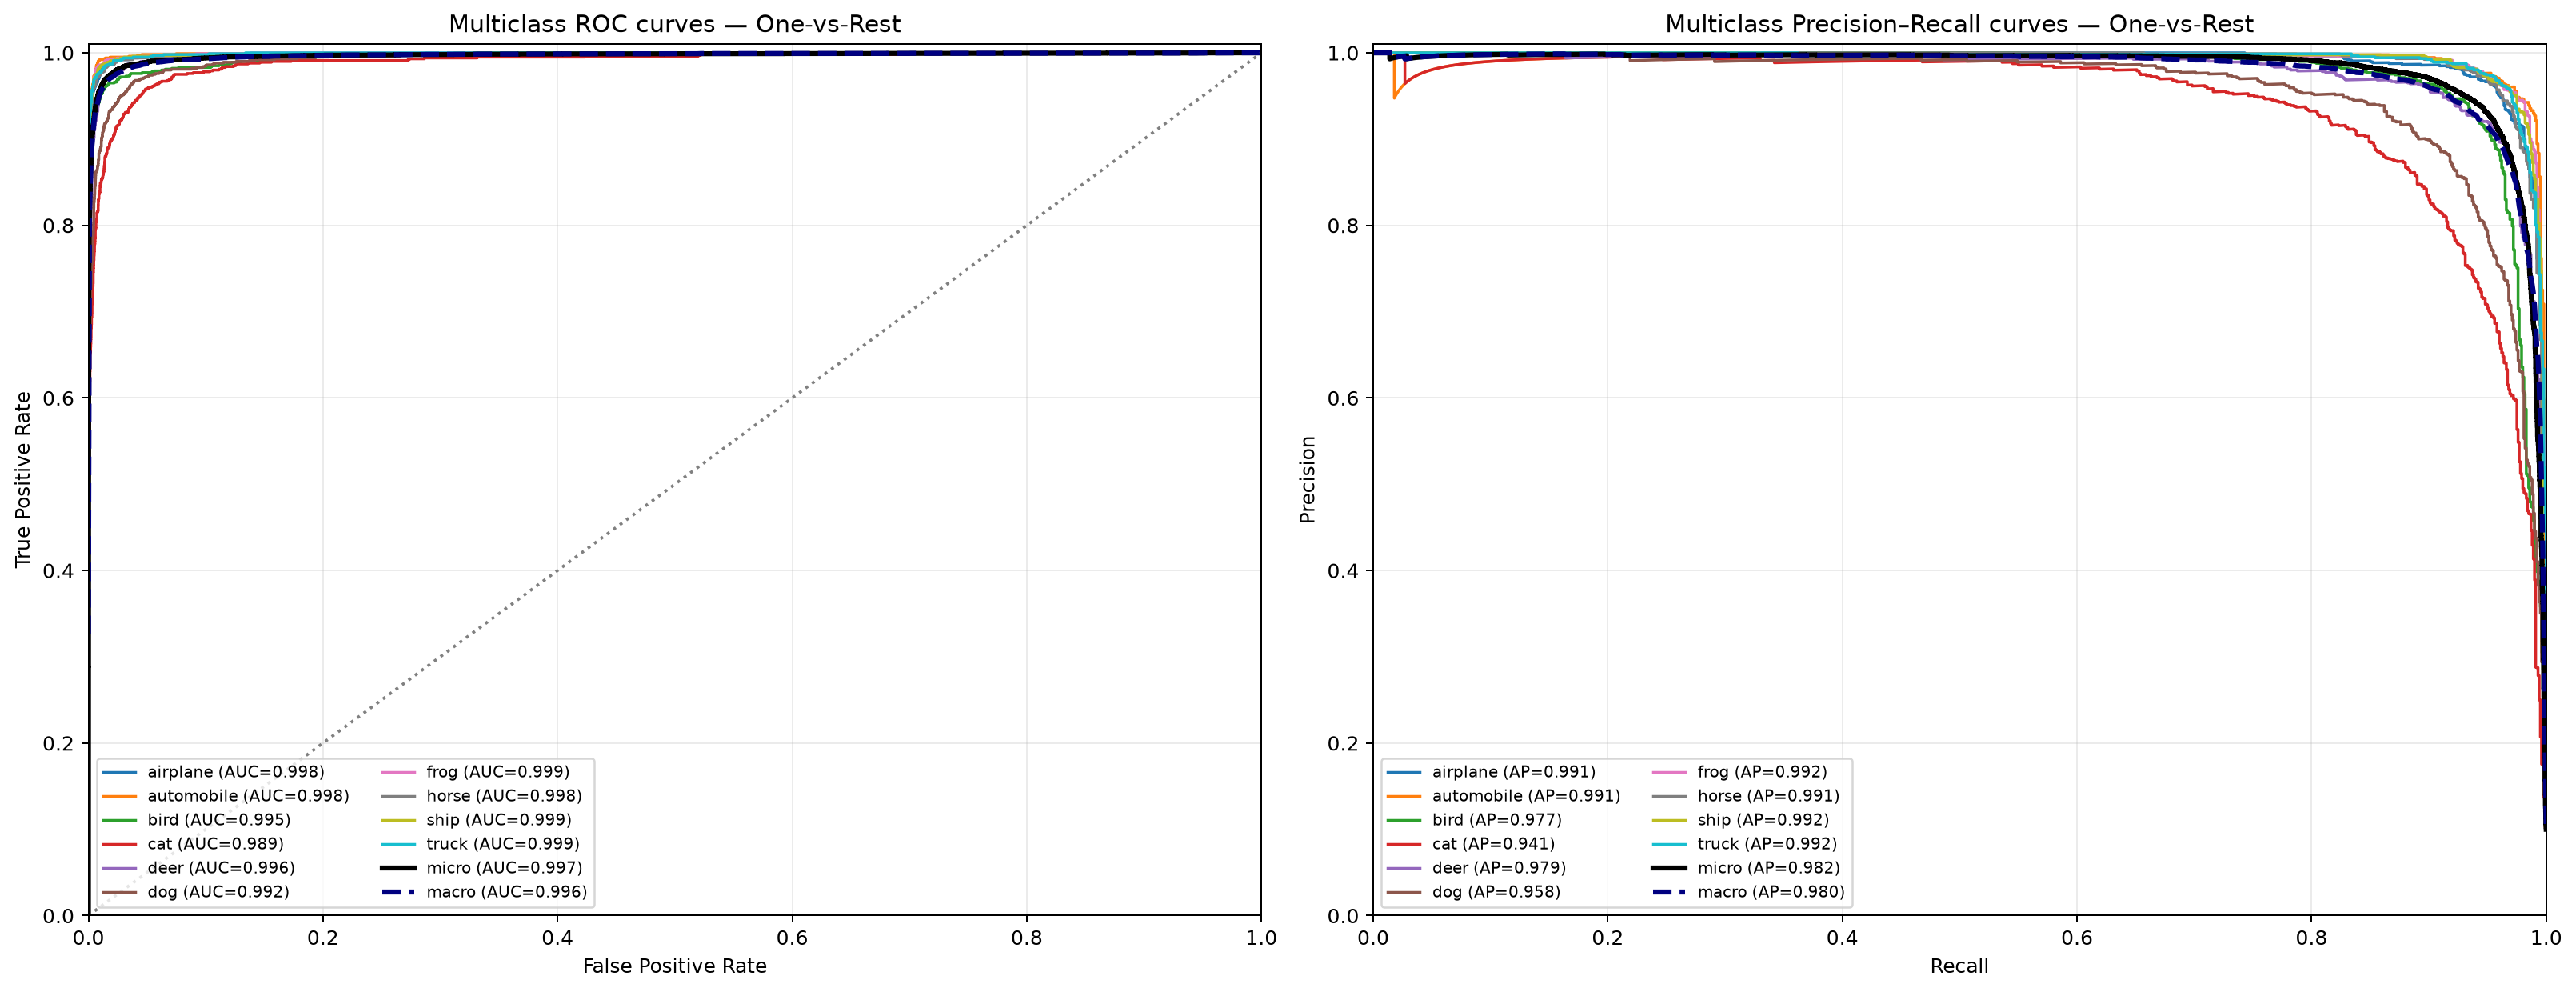

### Ground truth and prediction comparison

,sample_index,Ground truth,Prediction,Confidence,Correct
0,5426,dog,cat,0.982922,False
1,7559,ship,automobile,0.979535,False
2,6979,dog,deer,0.971854,False
3,9148,cat,dog,0.967628,False
4,1227,cat,dog,0.967334,False
5,2405,cat,frog,0.966797,False
6,7657,bird,dog,0.963579,False
7,9414,dog,cat,0.963023,False
8,4784,airplane,ship,0.960229,False
9,9227,automobile,truck,0.959832,False


### Per-class precision, recall and F1

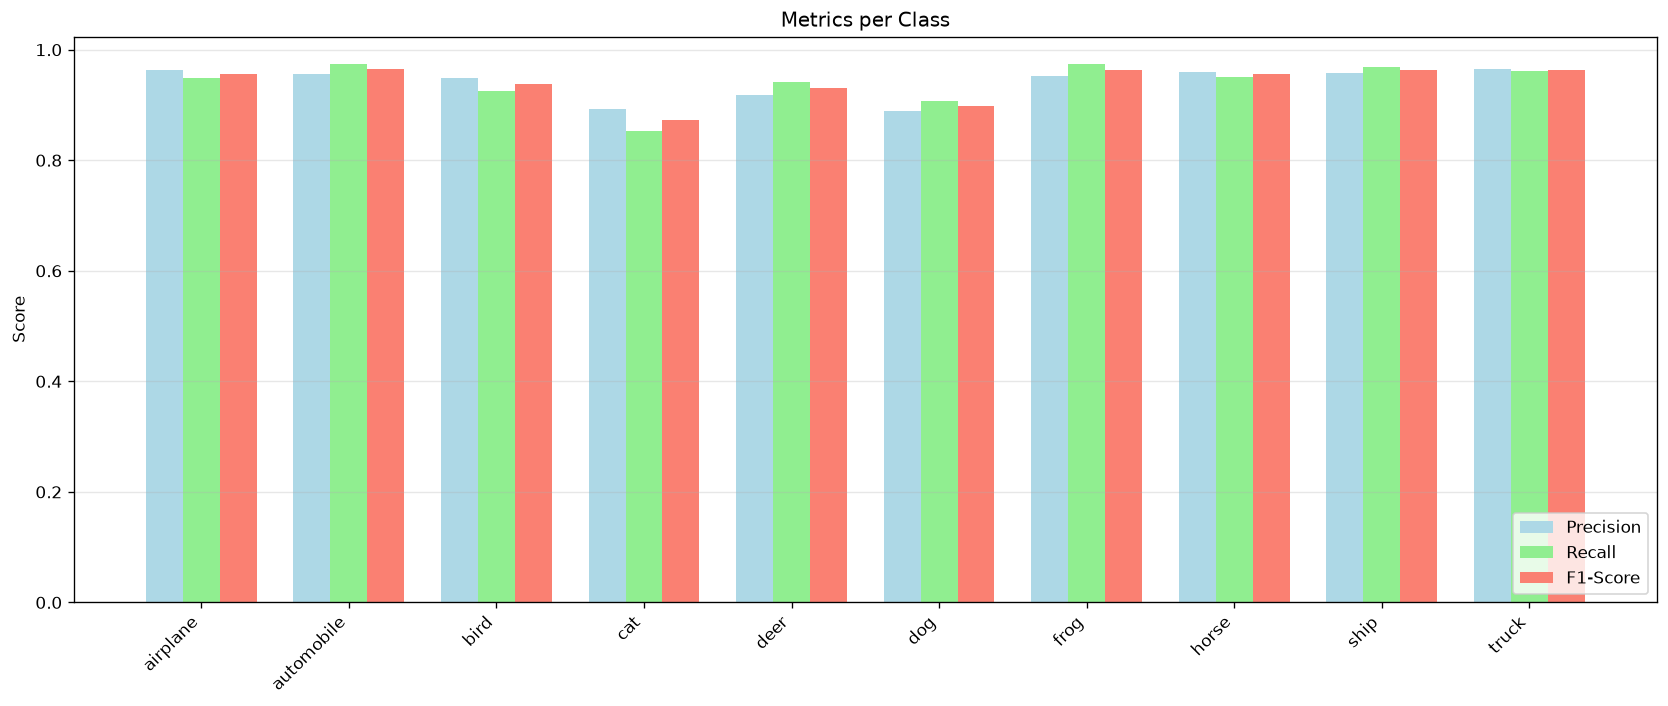

### Raw confusion matrix

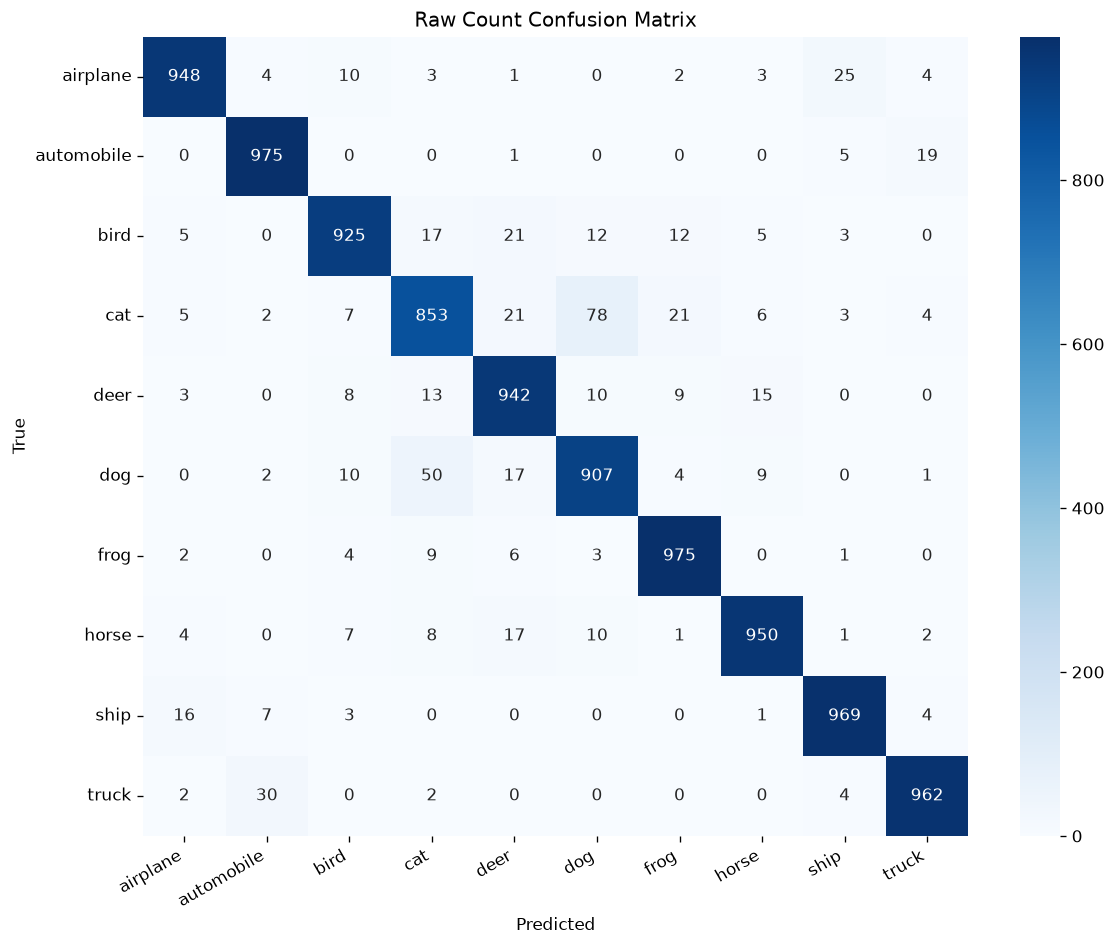

### Normalized confusion matrix

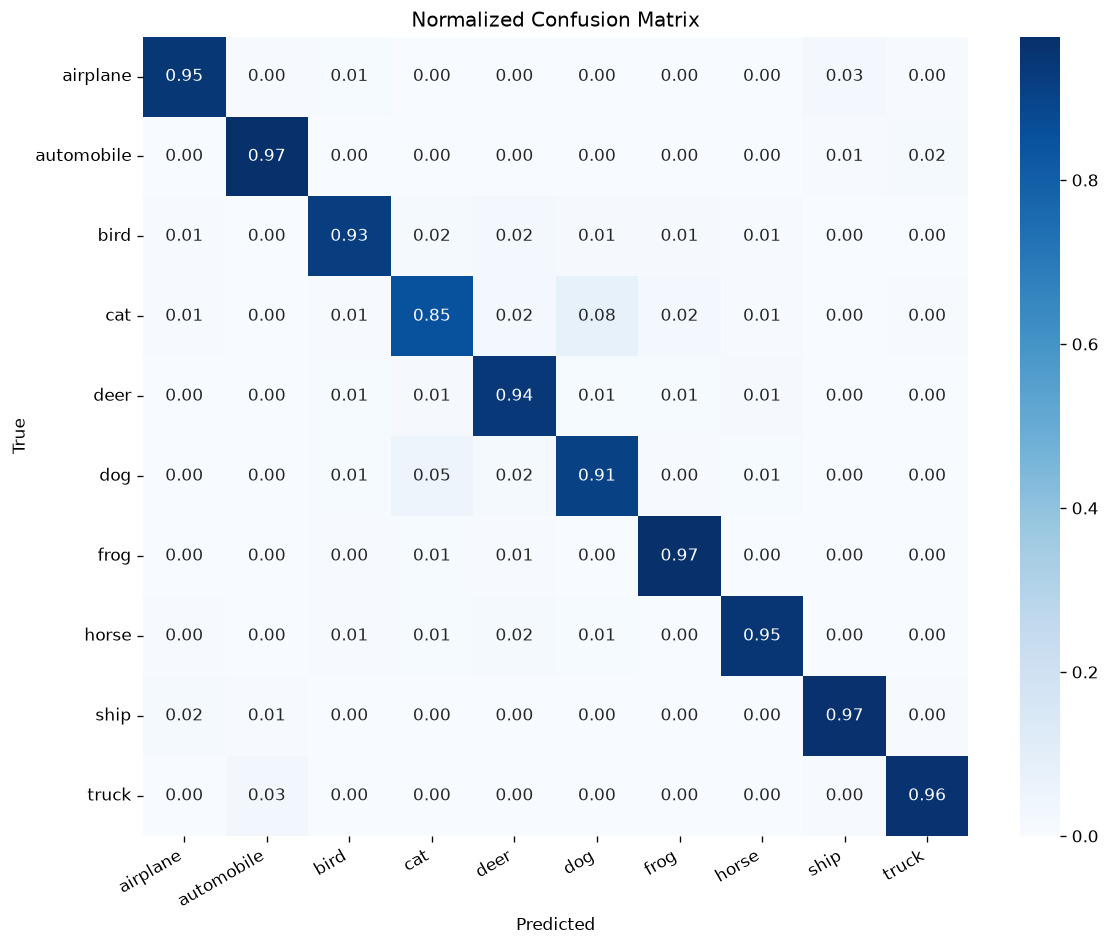

In [11]:
from processing_own_phase.final_evaluate import validate_final_artifacts

artifact_validation = validate_final_artifacts(output_dir=str(OUTPUT_DIR))
final_summary = json.loads((OUTPUT_DIR / "summary.json").read_text())
assert final_summary["validation_verification"] == "PASS"
assert final_summary["selection_source"] == "validation_only"
assert final_summary["test_evaluation_count"] == 1
assert artifact_validation["status"] == "PASS"

final_metrics = pd.DataFrame([
    {"Metric": "Test Accuracy", "Value": f"{final_summary['test_accuracy']:.2%}"},
    {"Metric": "Test Loss", "Value": f"{final_summary['test_loss']:.6f}"},
    {"Metric": "Macro Precision", "Value": f"{final_summary['macro_precision']:.6f}"},
    {"Metric": "Macro Recall", "Value": f"{final_summary['macro_recall']:.6f}"},
    {"Metric": "Macro F1", "Value": f"{final_summary['macro_f1']:.6f}"},
    {"Metric": "Test Samples", "Value": int(final_summary["test_samples"])},
])
display(colored_table(final_metrics, "Final Test Metrics — artifact derived"))

roc_pr_summary = json.loads((OUTPUT_DIR / "roc_pr_summary.json").read_text())
roc_pr_table = pd.DataFrame([
    {"class": class_name, **roc_pr_summary["per_class"][class_name]}
    for class_name in CLASS_NAMES
])
assert len(roc_pr_table) == len(CLASS_NAMES)
display(Markdown("### Locked One-vs-Rest ROC and Precision–Recall artifacts"))
display(colored_table(
    roc_pr_table,
    f"Per-class AUC/AP | micro ROC-AUC={roc_pr_summary['micro_roc_auc']:.6f} | micro AP={roc_pr_summary['micro_average_precision']:.6f}",
    gradient_columns=["roc_auc", "average_precision"],
))
display(Image(filename=str(OUTPUT_DIR / "roc_pr_curves_per_class.png")))

confusion_matrix = pd.read_csv(
    OUTPUT_DIR / "confusion_matrix.csv",
    index_col=0,
).to_numpy()
confusion_samples = int(confusion_matrix.sum())
confusion_accuracy = float(confusion_matrix.trace() / confusion_samples)
assert confusion_samples == int(final_summary["test_samples"])
assert abs(confusion_accuracy - final_summary["test_accuracy"]) <= 1e-12
print(
    "Confusion-matrix consistency: PASS | "
    f"samples={confusion_samples:,} | accuracy={confusion_accuracy:.2%}"
)

off_diagonal = confusion_matrix.copy()
np.fill_diagonal(off_diagonal, 0)
largest_confusions = []
for flat_index in np.argsort(off_diagonal, axis=None)[::-1][:5]:
    true_index, predicted_index = np.unravel_index(flat_index, off_diagonal.shape)
    largest_confusions.append({
        "True class": CLASS_NAMES[true_index],
        "Predicted as": CLASS_NAMES[predicted_index],
        "Count": int(off_diagonal[true_index, predicted_index]),
        "Rate within true class": (
            off_diagonal[true_index, predicted_index]
            / confusion_matrix[true_index].sum()
        ),
    })
display(colored_table(
    pd.DataFrame(largest_confusions),
    "Largest off-diagonal confusions",
    gradient_columns=["Count", "Rate within true class"],
))

generalization_plot_path = REPORTS_DIR / "validation_test_comparison_current.png"
plot_validation_test_comparison(
    validation_accuracy=final_summary["verified_val_accuracy"],
    test_accuracy=final_summary["test_accuracy"],
    validation_loss=final_summary["validation_loss"],
    test_loss=final_summary["test_loss"],
    save_path=str(generalization_plot_path),
)
display(Markdown("### Validation–Test generalization from official artifacts"))
display(Image(filename=str(generalization_plot_path)))

classification_report = pd.read_csv(OUTPUT_DIR / "classification_report.csv")
classification_report = (
    classification_report
    .set_index("class")
    .loc[CLASS_NAMES]
    .reset_index()
)
total_samples = int(confusion_matrix.sum())
true_positive = np.diag(confusion_matrix).astype(int)
false_negative = confusion_matrix.sum(axis=1).astype(int) - true_positive
false_positive = confusion_matrix.sum(axis=0).astype(int) - true_positive
true_negative = total_samples - true_positive - false_negative - false_positive
true_positive_rate = np.divide(
    true_positive,
    true_positive + false_negative,
    out=np.zeros(len(CLASS_NAMES), dtype=float),
    where=(true_positive + false_negative) != 0,
)
false_positive_rate = np.divide(
    false_positive,
    false_positive + true_negative,
    out=np.zeros(len(CLASS_NAMES), dtype=float),
    where=(false_positive + true_negative) != 0,
)
classification_report = classification_report.assign(
    TP=true_positive,
    TN=true_negative,
    FP=false_positive,
    FN=false_negative,
    TPR=true_positive_rate,
    FPR=false_positive_rate,
    class_accuracy=(true_positive + true_negative) / total_samples,
)
assert np.array_equal(
    classification_report["support"].to_numpy(dtype=int),
    true_positive + false_negative,
)
assert np.allclose(classification_report["recall"], classification_report["TPR"])
assert np.all(
    classification_report[["TP", "TN", "FP", "FN"]].sum(axis=1)
    == total_samples
)
display(Markdown("### Per-class classification report"))
display(colored_table(
    classification_report,
    "Per-class classification report",
    gradient_columns=[
        "precision", "recall", "f1-score", "support",
        "TP", "TN", "FP", "FN", "TPR", "FPR", "class_accuracy",
    ],
))

predictions = pd.read_csv(OUTPUT_DIR / "predictions.csv")
probability_columns = [f"probability_{class_name}" for class_name in CLASS_NAMES]
missing_probability_columns = sorted(set(probability_columns) - set(predictions.columns))
if missing_probability_columns:
    raise RuntimeError(
        "ROC and PR curves require per-class probability columns. "
        "Regenerate the official artifacts once with the updated export pipeline. "
        f"Missing: {', '.join(missing_probability_columns)}"
    )
probabilities = predictions[probability_columns].to_numpy(dtype=float)
ground_truth = predictions["true_label_id"].to_numpy(dtype=int)
predicted_labels = predictions["predicted_label_id"].to_numpy(dtype=int)
assert probabilities.shape == (total_samples, len(CLASS_NAMES))
assert np.isfinite(probabilities).all()
assert np.all((probabilities >= 0.0) & (probabilities <= 1.0))
assert np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6)
assert np.array_equal(probabilities.argmax(axis=1), predicted_labels)
assert np.array_equal(
    confusion_matrix,
    np.array([
        [np.sum((ground_truth == true_id) & (predicted_labels == predicted_id))
         for predicted_id in range(len(CLASS_NAMES))]
        for true_id in range(len(CLASS_NAMES))
    ]),
)

def binary_ranking_curves(binary_targets, scores):
    binary_targets = np.asarray(binary_targets, dtype=np.int64)
    scores = np.asarray(scores, dtype=float)
    positives = int(binary_targets.sum())
    negatives = len(binary_targets) - positives
    if positives == 0 or negatives == 0:
        raise ValueError("ROC and PR curves require positive and negative samples.")
    order = np.argsort(-scores, kind="mergesort")
    sorted_targets = binary_targets[order]
    sorted_scores = scores[order]
    threshold_indices = np.r_[np.flatnonzero(np.diff(sorted_scores)), len(scores) - 1]
    cumulative_tp = np.cumsum(sorted_targets)[threshold_indices]
    cumulative_fp = 1 + threshold_indices - cumulative_tp
    tpr = np.r_[0.0, cumulative_tp / positives]
    fpr = np.r_[0.0, cumulative_fp / negatives]
    recall = tpr
    precision = np.r_[1.0, cumulative_tp / (cumulative_tp + cumulative_fp)]
    roc_auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) * 0.5)
    average_precision = np.sum(np.diff(recall) * precision[1:])
    return fpr, tpr, recall, precision, roc_auc, average_precision

class_curves = {}
one_hot_ground_truth = np.eye(len(CLASS_NAMES), dtype=int)[ground_truth]
for class_index, class_name in enumerate(CLASS_NAMES):
    class_curves[class_name] = binary_ranking_curves(
        one_hot_ground_truth[:, class_index],
        probabilities[:, class_index],
    )
micro_curve = binary_ranking_curves(
    one_hot_ground_truth.ravel(),
    probabilities.ravel(),
)
curve_grid = np.linspace(0.0, 1.0, 1001)
macro_tpr = np.mean([
    np.interp(curve_grid, class_curves[class_name][0], class_curves[class_name][1])
    for class_name in CLASS_NAMES
], axis=0)
macro_precision = np.mean([
    np.interp(curve_grid, class_curves[class_name][2], class_curves[class_name][3])
    for class_name in CLASS_NAMES
], axis=0)
macro_roc_auc = np.sum(
    np.diff(curve_grid) * (macro_tpr[:-1] + macro_tpr[1:]) * 0.5
)
macro_average_precision = np.mean([
    class_curves[class_name][5] for class_name in CLASS_NAMES
])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for class_name in CLASS_NAMES:
    fpr, tpr, recall, precision, roc_auc, average_precision = class_curves[class_name]
    axes[0].plot(fpr, tpr, linewidth=1.4, label=f"{class_name} (AUC={roc_auc:.3f})")
    axes[1].plot(recall, precision, linewidth=1.4, label=f"{class_name} (AP={average_precision:.3f})")
axes[0].plot(micro_curve[0], micro_curve[1], color="black", linewidth=2.5, label=f"micro (AUC={micro_curve[4]:.3f})")
axes[0].plot(curve_grid, macro_tpr, color="navy", linestyle="--", linewidth=2.5, label=f"macro (AUC={macro_roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5)
axes[0].set(title="Multiclass ROC curves — One-vs-Rest", xlabel="False Positive Rate", ylabel="True Positive Rate", xlim=(0, 1), ylim=(0, 1.01))
axes[1].plot(micro_curve[2], micro_curve[3], color="black", linewidth=2.5, label=f"micro (AP={micro_curve[5]:.3f})")
axes[1].plot(curve_grid, macro_precision, color="navy", linestyle="--", linewidth=2.5, label=f"macro (AP={macro_average_precision:.3f})")
axes[1].set(title="Multiclass Precision–Recall curves — One-vs-Rest", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.01))
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(loc="lower left", fontsize=8, ncol=2)
fig.tight_layout()
roc_pr_notebook_path = REPORTS_DIR / "roc_pr_curves_notebook.png"
fig.savefig(roc_pr_notebook_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(Markdown("### Multiclass ROC and Precision–Recall curves — all 10 classes"))
display(Image(filename=str(roc_pr_notebook_path), width=1500))

correct_values = predictions["is_correct"].to_numpy()
if not np.issubdtype(correct_values.dtype, np.bool_):
    correct_values = np.char.lower(correct_values.astype(str)) == "true"
correct_mask = pd.Series(correct_values, index=predictions.index, dtype=bool)
ground_truth_prediction = pd.concat([
    predictions.loc[~correct_mask].nlargest(15, "confidence"),
    predictions.loc[correct_mask].nsmallest(15, "confidence"),
])
ground_truth_prediction.index.name = "sample_index"
ground_truth_prediction = ground_truth_prediction.reset_index()
ground_truth_prediction = ground_truth_prediction.rename(columns={
    "true_label": "Ground truth",
    "predicted_label": "Prediction",
    "confidence": "Confidence",
    "is_correct": "Correct",
})[["sample_index", "Ground truth", "Prediction", "Confidence", "Correct"]]
display(Markdown("### Ground truth and prediction comparison"))
display(colored_table(
    ground_truth_prediction,
    "Ground truth vs prediction — confident errors and challenging correct cases",
    gradient_columns=["Confidence"],
    boolean_columns=["Correct"],
))

for filename, title in (
    ("metrics_bar.png", "Per-class precision, recall and F1"),
    ("confusion_matrix_raw.png", "Raw confusion matrix"),
    ("confusion_matrix_normalized.png", "Normalized confusion matrix"),
):
    display(Markdown(f"### {title}"))
    display(Image(filename=str(REPORTS_DIR / filename)))

## Phase 11 - Integrated Results Dashboard and Error Analysis

The classification report, predictions, confusion matrices and confidence plots below were regenerated from the verified E2 checkpoint. Error analysis focuses on class-level weaknesses and confident mistakes rather than only the aggregate accuracy.

The official artifacts support the following analysis:

1. Per-class precision, recall and F1.
2. The largest off-diagonal confusion-matrix entries.
3. High-confidence incorrect predictions.
4. Low-confidence correct predictions.
5. Image-quality patterns such as blur, small objects, background shortcuts and crop sensitivity.
6. Whether common semantic pairs such as cat/dog or automobile/truck dominate the errors.

The notebook now computes the largest off-diagonal confusion pairs directly from `confusion_matrix.csv`. Each proposed improvement should address one observed root cause and change only one experimental factor before re-evaluation.

In [12]:
from processing_own_phase.visualization_data import build_visualization_data
from processing_own_phase.training_dashboard import render_training_dashboard

visualization_data_path = OUTPUT_DIR / "visualization_data.json"
build_visualization_data(
    project_root=PROJECT_ROOT,
    output_path=visualization_data_path,
)

render_training_dashboard(
    visualization_data_path=visualization_data_path,
    save_path=REPORTS_DIR / "practice_2_training_dashboard.html",
)

TrainingDashboard(html='<div id="practice2-training-dashboard">\n<style>\n#practice2-training-dashboard{--bg:#f7f8fa;--surface:#fff;--text:#172033;--muted:#617087;--border:#d9dee8;--grid:#e7eaf0;--accent:#2457a6;--soft:#eaf1fb;--ok:#167447;--bad:#a13b3b;--c1:#2457a6;--c2:#d97925;--c3:#aa3d61;--c4:#148168;--c5:#7453a6;font-family:Inter,ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;color:var(--text);background:var(--bg);padding:22px;border:1px solid var(--border);border-radius:12px;line-height:1.45}\n@media(prefers-color-scheme:dark){#practice2-training-dashboard{--bg:#111722;--surface:#182131;--text:#edf2fa;--muted:#aeb9ca;--border:#344055;--grid:#2a3547;--accent:#8bb8ff;--soft:#1d3150;--ok:#65d59a;--bad:#ff9b9b;--c1:#8bb8ff;--c2:#ffb36b;--c3:#f48bab;--c4:#65d59a;--c5:#c0a1ff}}\n#practice2-training-dashboard *{box-sizing:border-box}#practice2-training-dashboard h1{margin:0;font-size:1.65rem;font-weight:500}#practice2-training-dashboard h2{margin:30px 0 12px;font-size:1.2rem;font-weight:500;border-bottom:1px solid var(--border);padding-bottom:7px}#practice2-training-dashboard h3{margin:8px 0;font-size:1rem;font-weight:500}#practice2-training-dashboard .p2d-subtitle{color:var(--muted);margin:4px 0 18px}.p2d-overview{display:grid;grid-template-columns:repeat(auto-fit,minmax(165px,1fr));gap:10px}.p2d-stat{background:var(--surface);border:1px solid var(--border);border-radius:8px;padding:11px 12px;min-width:0}.p2d-stat span,.p2d-final span{display:block;color:var(--muted);font-size:.82rem}.p2d-stat strong,.p2d-final strong{display:block;margin-top:4px;font-weight:500;overflow-wrap:anywhere}.p2d-chart-grid{display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:18px}.p2d-chart{min-width:0}.p2d-chart svg{display:block;width:100%;height:auto}.p2d-chart svg text{fill:var(--muted);font-size:11px}.p2d-frame{fill:var(--surface);stroke:var(--border)}.p2d-grid{stroke:var(--grid);stroke-width:1}.p2d-zero{stroke:var(--muted);stroke-width:1}.p2d-line{fill:none;stroke-width:2}.p2d-c1{stroke:var(--c1);color:var(--c1)}.p2d-c2{stroke:var(--c2);color:var(--c2)}.p2d-c3{stroke:var(--c3);color:var(--c3)}.p2d-c4{stroke:var(--c4);color:var(--c4)}.p2d-c5{stroke:var(--c5);color:var(--c5)}.p2d-marker{stroke-width:1.25;stroke-dasharray:5 4}.p2d-marker-label{fill:var(--text)!important}.p2d-legend{display:flex;gap:14px;flex-wrap:wrap;color:var(--muted);font-size:.82rem;margin-bottom:3px}.p2d-legend i{display:inline-block;width:15px;border-top:3px solid currentColor;margin-right:5px;vertical-align:middle}.p2d-table-wrap{overflow-x:auto;border:1px solid var(--border);border-radius:8px;background:var(--surface)}table{border-collapse:collapse;width:100%;font-size:.86rem}th,td{padding:8px 10px;border-bottom:1px solid var(--border);text-align:right;white-space:nowrap}th:first-child,td:first-child{text-align:left}thead th{background:var(--soft);font-weight:500}tbody tr:last-child td,tbody tr:last-child th{border-bottom:0}.p2d-selected{background:var(--soft);font-weight:500}.p2d-ok{color:var(--ok)}.p2d-missing{color:var(--bad)}code{color:inherit}.p2d-final{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:10px}.p2d-final>div{border-left:3px solid var(--accent);padding:7px 11px;background:var(--surface)}.p2d-readonly,.p2d-empty{color:var(--muted)}.p2d-error-grid{display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:18px}.p2d-confusion td{background:color-mix(in srgb,var(--accent) calc(var(--heat)*100%),var(--surface));text-align:center}.p2d-warnings{margin-top:18px;color:var(--muted)}.p2d-warnings summary{cursor:pointer}.p2d-warnings li{margin:4px 0}@media(max-width:760px){#practice2-training-dashboard{padding:14px}.p2d-chart-grid,.p2d-error-grid{grid-template-columns:1fr}}\n</style><h1>Practice 2 — Training Dashboard</h1><p class="p2d-subtitle">Saved-artifact view of the selected CIFAR-10 transfer-learning run.</p><div class="p2d-overview"><div class="p2d-stat"><span>Run ID</span><strong>E2_resne

### Confidence distribution

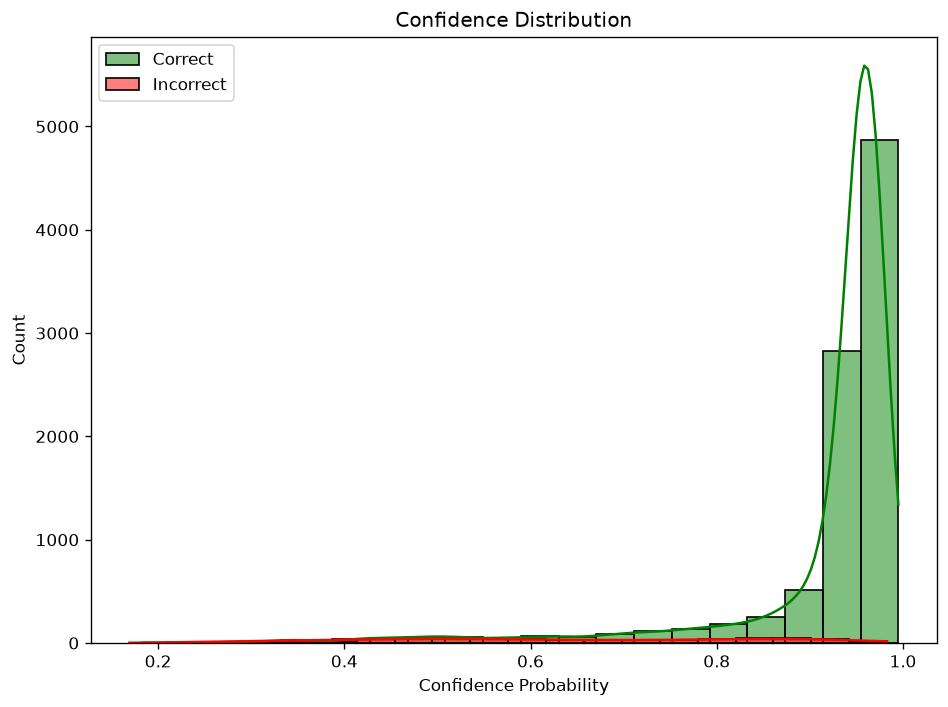

### Highest-confidence correct predictions

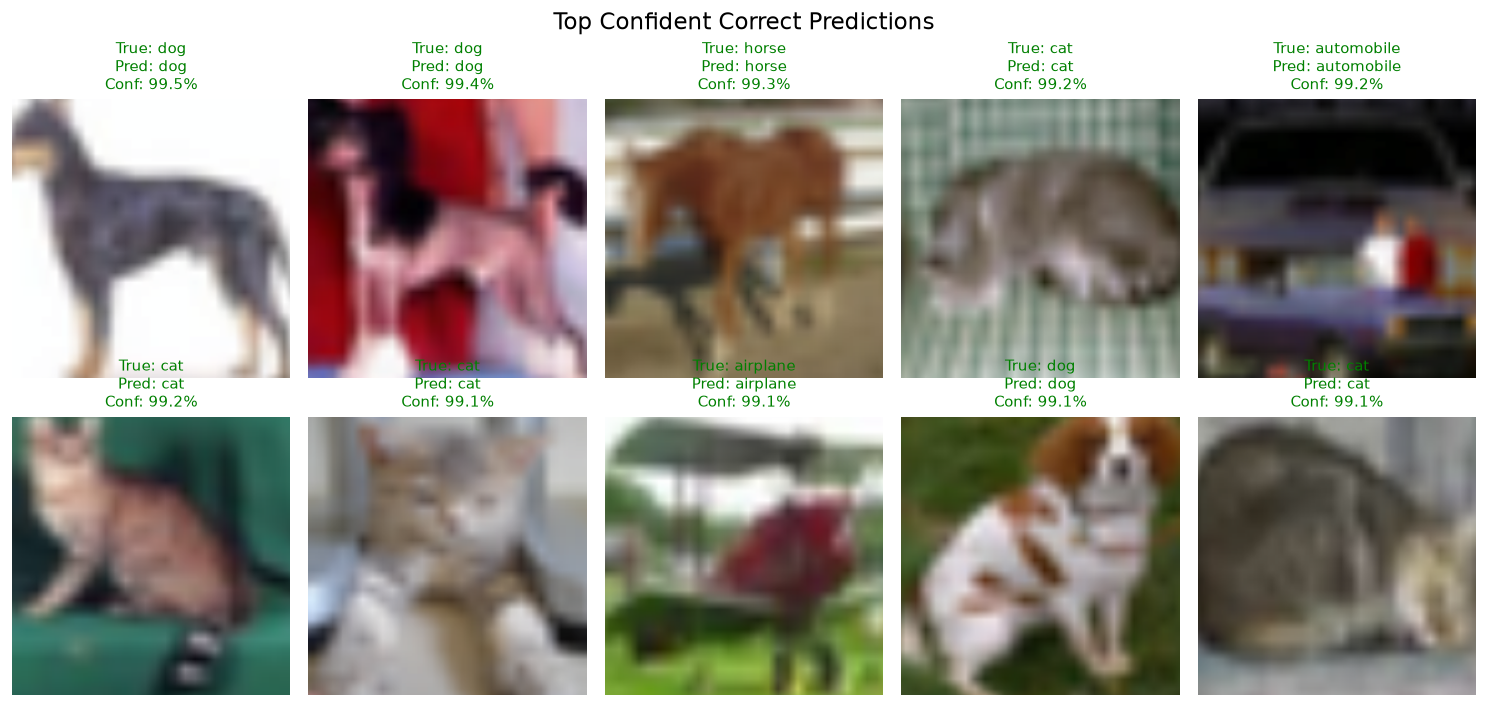

### Highest-confidence incorrect predictions

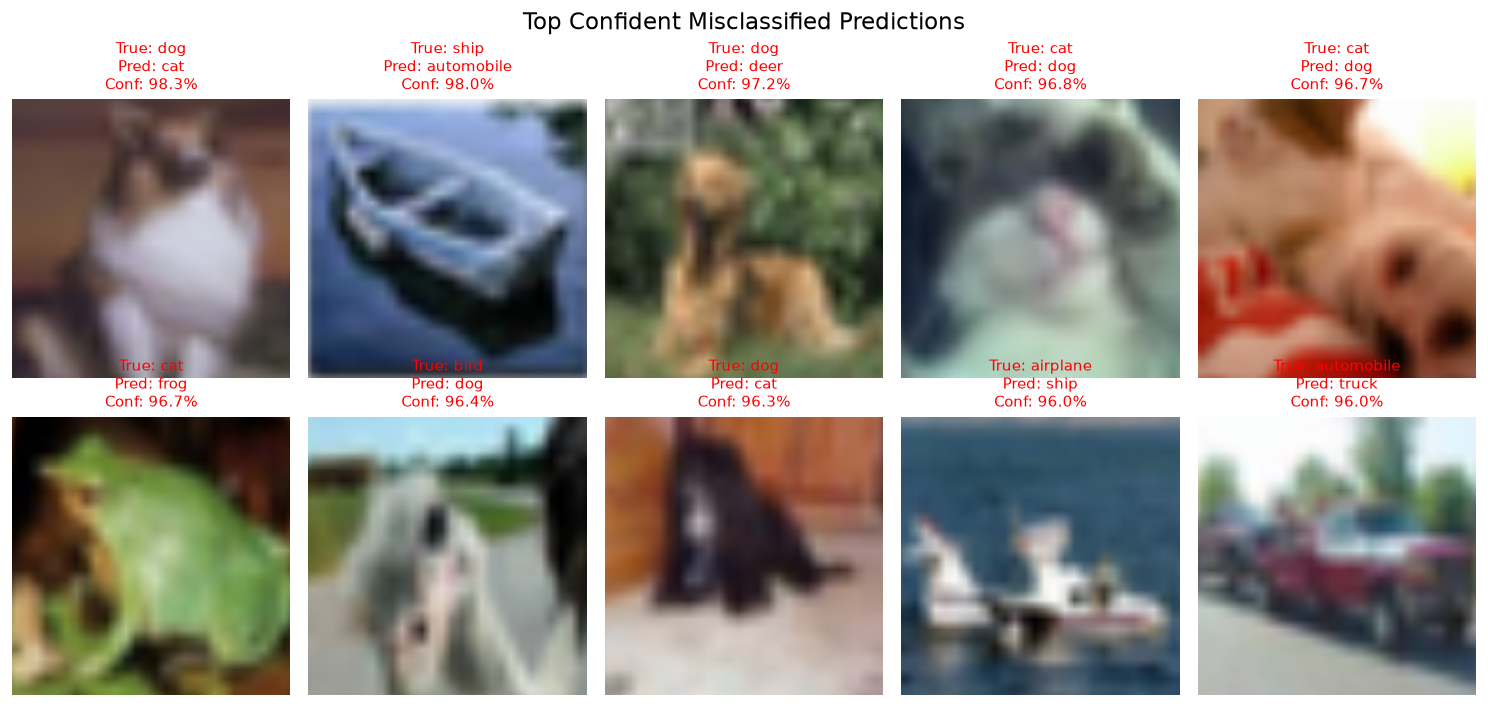

### Mixed prediction grid

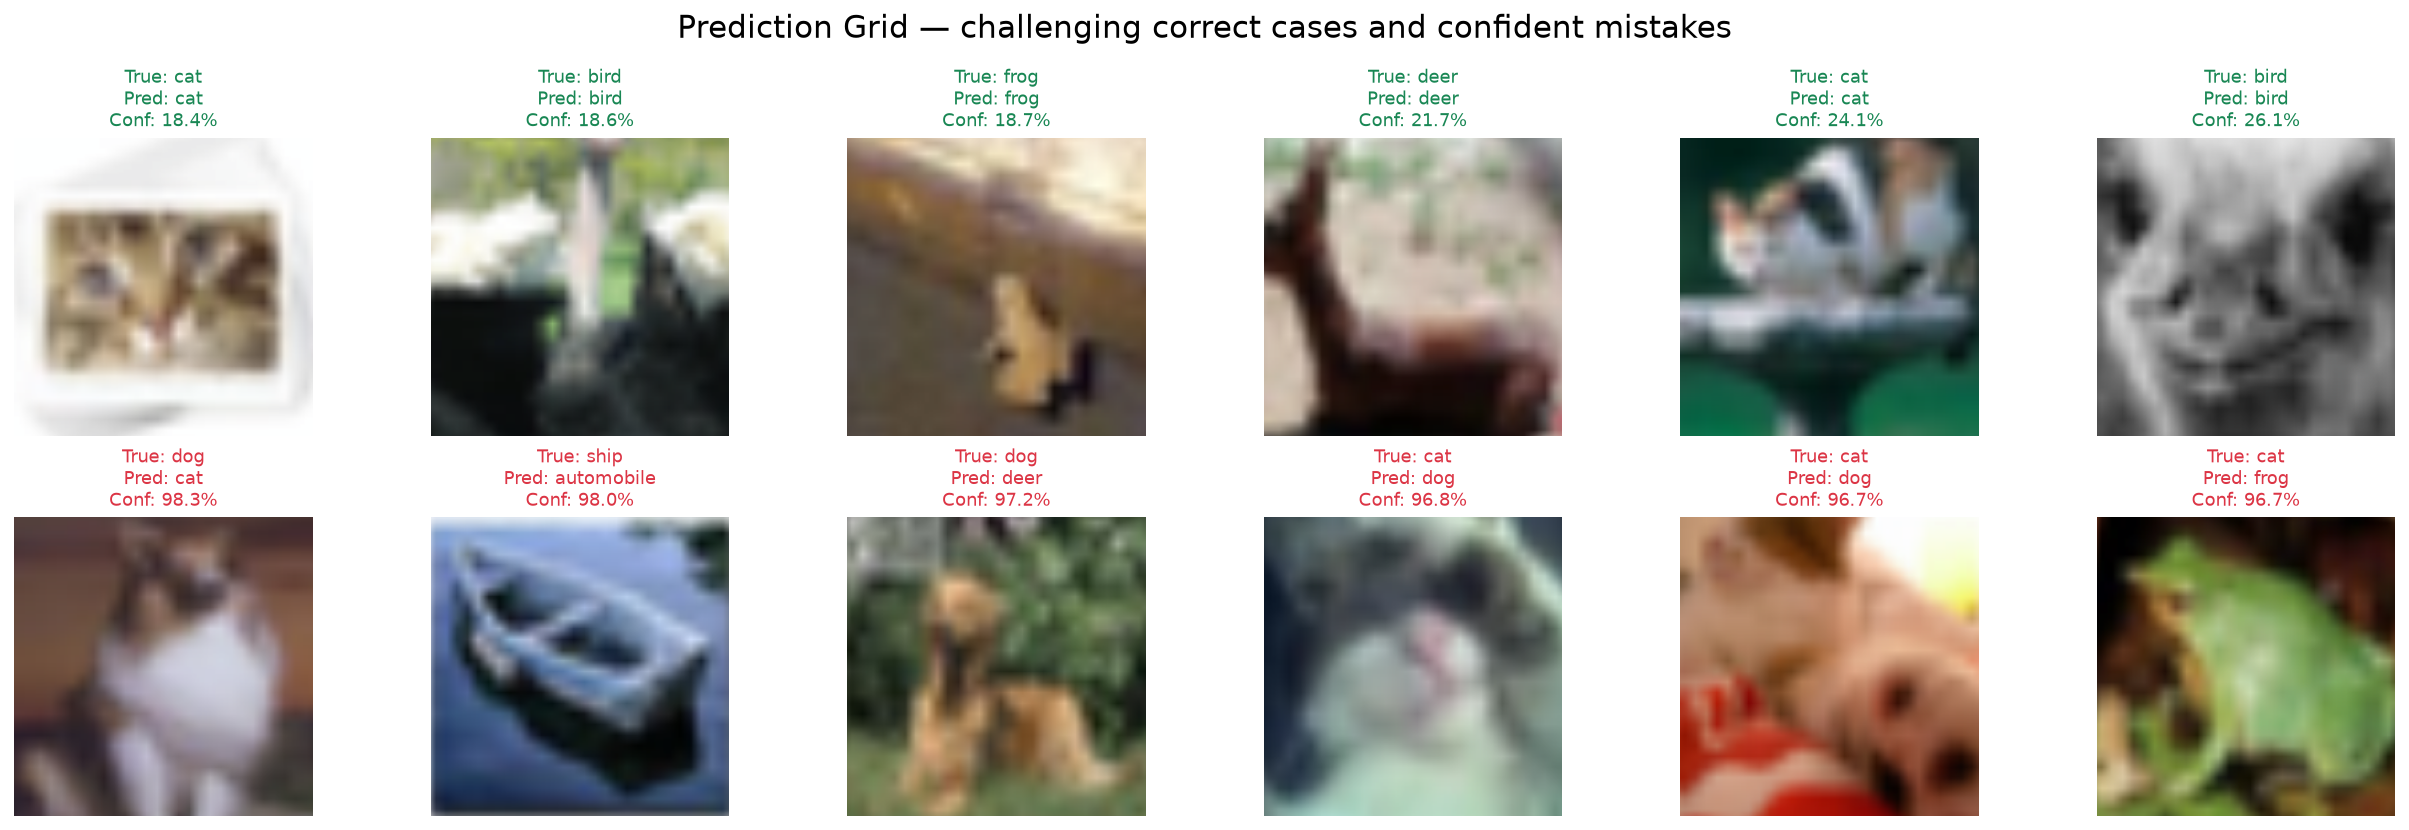

In [13]:
for filename, title in (
    ("confidence_distribution.png", "Confidence distribution"),
    ("prediction_gallery_correct.png", "Highest-confidence correct predictions"),
    ("prediction_gallery_incorrect.png", "Highest-confidence incorrect predictions"),
):
    display(Markdown(f"### {title}"))
    display(Image(filename=str(REPORTS_DIR / filename)))

predictions = pd.read_csv(OUTPUT_DIR / "predictions.csv")
correct_mask = predictions["is_correct"]
if correct_mask.dtype != bool:
    correct_mask = correct_mask.astype(str).str.lower().eq("true")
challenging_correct = predictions[correct_mask].nsmallest(6, "confidence").copy()
challenging_correct["case"] = "Challenging correct"
confident_mistakes = predictions[~correct_mask].nlargest(6, "confidence").copy()
confident_mistakes["case"] = "Confident mistake"
prediction_grid = pd.concat([challenging_correct, confident_mistakes])

imagenet_mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
imagenet_std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax, (dataset_index, row) in zip(axes.flat, prediction_grid.iterrows()):
    image_tensor, _ = test_dataset[int(dataset_index)]
    image = image_tensor.numpy().transpose(1, 2, 0)
    image = np.clip(image * imagenet_std + imagenet_mean, 0, 1)
    ax.imshow(image)
    title_color = "#198754" if row["case"] == "Challenging correct" else "#dc3545"
    ax.set_title(
        f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.1%}",
        color=title_color,
        fontsize=9,
    )
    ax.axis("off")
fig.suptitle(
    "Prediction Grid — challenging correct cases and confident mistakes",
    fontsize=16,
)
fig.tight_layout()
prediction_grid_path = REPORTS_DIR / "prediction_grid_mixed.png"
fig.savefig(prediction_grid_path, dpi=140, bbox_inches="tight")
plt.close(fig)
display(Markdown("### Mixed prediction grid"))
display(Image(filename=str(prediction_grid_path)))

In [14]:
display(Markdown(
    "**Artifact status:** PASS — summary, predictions and confusion matrix "
    "agree on sample count and accuracy."
))

**Artifact status:** PASS — summary, predictions and confusion matrix agree on sample count and accuracy.

### Bias–variance and training diagnostics

Learning curves should be interpreted before proposing a more complex model:

| Pattern | Interpretation | Candidate action |
|---|---|---|
| High train and validation error, small gap | Underfitting/high bias | Unfreeze more layers, train longer or improve optimization |
| Low train error, much higher validation error | Overfitting/high variance | Stronger augmentation, regularization or earlier stopping |
| Low errors and small gap | Better generalization | Confirm stability across seeds |

The official comparison now uses the same five-epoch budget for controlled E1/E2 runs. Validation peaked before the final epoch for the selected model, so retaining `best.pt` rather than the last checkpoint was appropriate. The remaining limitation is statistical stability: one seed cannot establish mean performance or variance.

### Interpretability

For CNN image classification, Grad-CAM, saliency maps or occlusion sensitivity are more appropriate than tabular-oriented tools such as VIF or manual ratio features.

A future Grad-CAM analysis should verify whether the selected model attends to the object rather than background shortcuts. This notebook does not claim interpretability evidence until real Grad-CAM artifacts are generated.

## Phase 12 - Save/Load Verification, Limitations and Conclusion

### Reproducibility and save/load checklist

- Fixed seed and saved split policy.
- Explicit train versus evaluation transforms.
- Config captured per run.
- TensorBoard events and text logs stored by run ID.
- Best checkpoint path stored in experiment metadata.
- Checkpoint contains architecture and training-strategy metadata.
- Reloaded validation accuracy checked before final test.
- Internal accuracy stored in `[0, 1]`; percentage conversion only for display.
- Future full results should include several seeds and report mean ± standard deviation.

### Conclusion

- The project implements an end-to-end transfer-learning pipeline for CIFAR-10.
- ResNet18 head-only is the implementation baseline.
- ResNet18 partial fine-tuning was selected using Validation accuracy only.
- Cell 21 reloads `best.pt` and requires exact Validation reproduction before final results are accepted.
- Cell 23 reads all Final Test metrics from official artifacts, verifies confusion-matrix consistency and visualizes the Validation–Test gap.
- Phase 11 includes both focused correct/incorrect galleries and a mixed prediction grid for error analysis.
- Invalid results from earlier unverified evaluation paths are excluded.
- Future work should measure stability across multiple seeds and extend class-level error analysis.

This notebook remains a presentation and analysis document. Training, evaluation and checkpoint logic must continue to live in the reusable source modules.